# Wafer Map Classification with Convolutional Neural Networks

This notebook compares a controlled sequence of CNN configurations for wafer-map classification.

The data protocol is fixed before model development. A stratified 65%/15%/20% split is created from the full labeled dataset. The 3,000-sample cap is applied only to the training partition and independently for each class. Validation data guide training and model comparison. The large, naturally distributed test set is evaluated only after every architecture and optimizer configuration has been fixed.

Arbitrary-angle rotation is intentionally retained as a didactic experiment. Wafer maps contain discrete values, so interpolated rotations can create artificial intermediate values. The following safe-augmentation experiment isolates this effect.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers import Adam, Nadam, RMSprop, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

In [ ]:
import sys
from pathlib import Path


def find_repository_root(start_path=None):
    current_path = (
        Path.cwd()
        if start_path is None
        else Path(start_path)
    ).resolve()

    for candidate in (current_path, *current_path.parents):
        has_project = (candidate / "project").is_dir()
        has_datasets = (candidate / "datasets").is_dir()

        if has_project and has_datasets:
            return candidate

    raise FileNotFoundError(
        "Repository root not found. Expected directories "
        "'project' and 'datasets' in the same location."
    )


REPO_ROOT = find_repository_root()
PROJECT_DIR = REPO_ROOT / "project"
DATASETS_DIR = REPO_ROOT / "datasets"

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

In [5]:
from utils import (
    build_optimized_model,
    cap_indices_per_class,
    evaluate_classifier,
    plot_confusion_matrix,
    plot_training_history,
    resize_wafer_maps,
    set_global_determinism,
    visualize_original_and_maps,
    visualize_wafer_samples,
    make_macro_f1_callbacks
)

## Configuration

The dataset path is the only project-specific setting. Checkpoints, split indices, and result tables are stored under `cnn_outputs`.

In [6]:
DATASET_PATH = DATASETS_DIR / "Dataset.pkl"
OUTPUT_DIR = PROJECT_DIR / "cnn_outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"

TARGET_SHAPE = (56, 56)
MAX_SAMPLES_PER_CLASS = 3000

TRAIN_FRACTION = 0.65
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.20

BATCH_SIZE = 128
PREDICTION_BATCH_SIZE = 256
MAX_EPOCHS = 50

EXPECTED_CLASSES = [
    "center",
    "donut",
    "edge-loc",
    "edge-ring",
    "loc",
    "near-full",
    "none",
    "random",
    "scratch",
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

assert np.isclose(
    TRAIN_FRACTION + VALIDATION_FRACTION + TEST_FRACTION,
    1.0,
)

In [7]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], "GPU")
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print(f"Using GPU: {gpus[0].name}")
    except RuntimeError as error:
        print(f"GPU configuration was already initialized: {error}")
else:
    print("No GPU detected. TensorFlow will use the CPU.")

set_global_determinism(SEED, clear_session=False)

Using GPU: /physical_device:GPU:0


## Dataset preparation

Only the nine documented wafer classes are retained. Empty or unsupported labels are excluded before encoding and splitting.

In [8]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATASET_PATH.resolve()}. "
        "Update DATASET_PATH before running the notebook."
    )

df = pd.read_pickle(DATASET_PATH)

required_columns = {"waferMap", "failureType"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise KeyError(f"Missing required columns: {sorted(missing_columns)}")

df = df[df["failureType"].isin(EXPECTED_CLASSES)].reset_index(drop=True)

missing_expected_classes = sorted(
    set(EXPECTED_CLASSES).difference(df["failureType"].unique())
)
if missing_expected_classes:
    raise ValueError(
        f"The dataset is missing expected classes: {missing_expected_classes}"
    )

print(f"Labeled wafer maps: {len(df):,}")
display(df.head())

Labeled wafer maps: 172,950


,waferMap,dieSize,lotName,waferIndex,trainTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,training,none
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,training,none
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,training,none
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,training,none
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,training,none


,Samples,Share (%)
failureType,,
center,4294,2.482798
donut,555,0.320902
edge-loc,5189,3.000289
edge-ring,9680,5.596993
loc,3593,2.077479
near-full,149,0.086152
none,147431,85.244868
random,866,0.500723
scratch,1193,0.689795


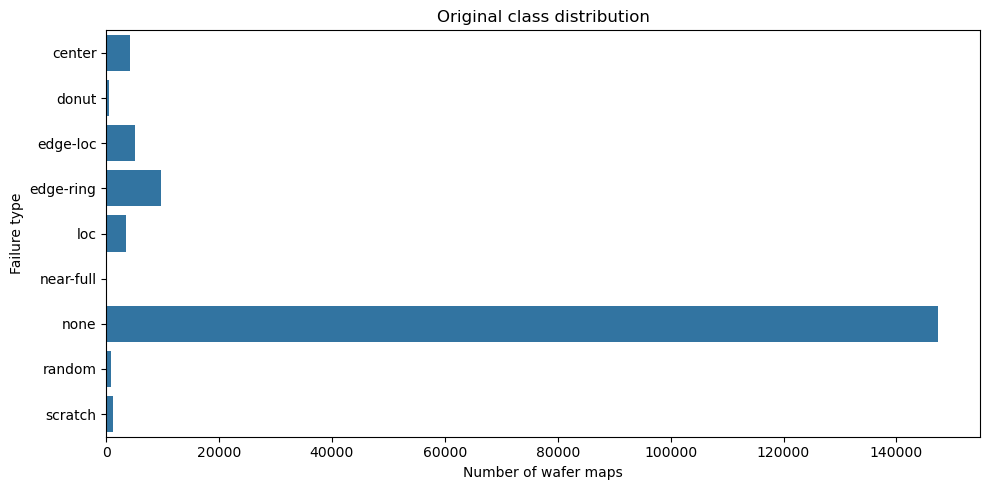

In [9]:
class_counts = (
    df["failureType"]
    .value_counts()
    .reindex(EXPECTED_CLASSES)
    .rename("Samples")
    .to_frame()
)
class_counts["Share (%)"] = class_counts["Samples"] / len(df) * 100

display(class_counts)

plt.figure(figsize=(10, 5))
axis = sns.barplot(
    data=class_counts.reset_index(),
    x="Samples",
    y="failureType",
)
axis.set_title("Original class distribution")
axis.set_xlabel("Number of wafer maps")
axis.set_ylabel("Failure type")
plt.tight_layout()
plt.show()

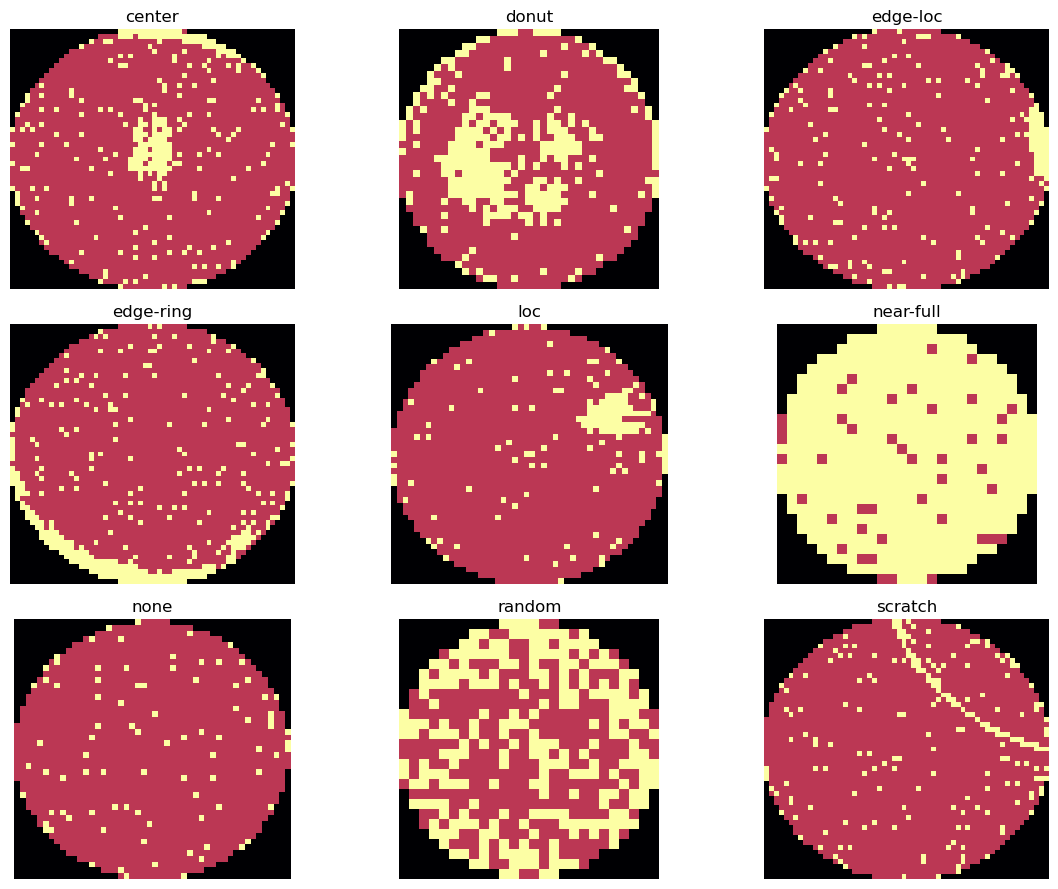

In [10]:
visualize_wafer_samples(df)

## Fixed train, validation, and test partitions

The split is stratified at image level. The final test partition keeps its natural class distribution and is never capped. Samples removed by the training cap are left unused; they are not moved into validation or test.

A lot-level split would be preferable when the target is strict generalization to unseen manufacturing lots. This notebook keeps the agreed stratified image-level protocol so that every rare class is represented in all three partitions.

In [11]:
encoder = LabelEncoder()
y_all = encoder.fit_transform(df["failureType"])
class_names = encoder.classes_
num_classes = len(class_names)
all_indices = np.arange(len(df), dtype=np.int64)

train_validation_indices, test_indices = train_test_split(
    all_indices,
    test_size=TEST_FRACTION,
    random_state=SEED,
    stratify=y_all,
)

validation_share_within_train_validation = (
    VALIDATION_FRACTION / (TRAIN_FRACTION + VALIDATION_FRACTION)
)

train_pool_indices, validation_indices = train_test_split(
    train_validation_indices,
    test_size=validation_share_within_train_validation,
    random_state=SEED,
    stratify=y_all[train_validation_indices],
)

train_indices = cap_indices_per_class(
    train_pool_indices,
    labels=y_all,
    max_samples_per_class=MAX_SAMPLES_PER_CLASS,
    seed=SEED,
)

assert len(np.intersect1d(train_indices, validation_indices)) == 0
assert len(np.intersect1d(train_indices, test_indices)) == 0
assert len(np.intersect1d(validation_indices, test_indices)) == 0
assert set(train_indices).issubset(set(train_pool_indices))
assert np.bincount(
    y_all[train_indices],
    minlength=num_classes,
).max() <= MAX_SAMPLES_PER_CLASS

np.savez_compressed(
    OUTPUT_DIR / "split_indices.npz",
    train_pool_indices=train_pool_indices,
    train_indices=train_indices,
    validation_indices=validation_indices,
    test_indices=test_indices,
)

print(f"Training pool before cap: {len(train_pool_indices):,}")
print(f"Training set after cap:   {len(train_indices):,}")
print(f"Validation set:           {len(validation_indices):,}")
print(f"Large test set:           {len(test_indices):,}")

Training pool before cap: 112,417
Training set after cap:   15,923
Validation set:           25,943
Large test set:           34,590


In [ ]:
def distribution_for(indices, column_name):
    counts = np.bincount(y_all[indices], minlength=num_classes)
    return pd.Series(counts, index=class_names, name=column_name)


split_distribution = pd.concat(
    [
        distribution_for(train_pool_indices, "Training pool"),
        distribution_for(train_indices, "Training after cap"),
        distribution_for(validation_indices, "Validation"),
        distribution_for(test_indices, "Large test"),
    ],
    axis=1,
)

display(split_distribution)

,Training pool,Training after cap,Validation,Large test
center,2791,2791,644,859
donut,361,361,83,111
edge-loc,3372,3000,779,1038
edge-ring,6292,3000,1452,1936
loc,2336,2336,539,718
near-full,97,97,22,30
none,95830,3000,22115,29486
random,563,563,130,173
scratch,775,775,179,239


## Resizing

Nearest-neighbor interpolation preserves the discrete wafer-map states. The arrays remain unsigned integers with values 0, 1, and 2. Normalization to 0, 0.5, and 1 is performed inside the model, avoiding large duplicated floating-point arrays.

In [13]:
X_train = resize_wafer_maps(
    df.iloc[train_indices],
    target_shape=TARGET_SHAPE,
)
X_validation = resize_wafer_maps(
    df.iloc[validation_indices],
    target_shape=TARGET_SHAPE,
)
X_test = resize_wafer_maps(
    df.iloc[test_indices],
    target_shape=TARGET_SHAPE,
)

y_train = y_all[train_indices]
y_validation = y_all[validation_indices]
y_test = y_all[test_indices]

y_train_categorical = to_categorical(
    y_train,
    num_classes=num_classes,
)
y_validation_categorical = to_categorical(
    y_validation,
    num_classes=num_classes,
)

print(f"Training features:   {X_train.shape}, {X_train.dtype}")
print(f"Validation features: {X_validation.shape}, {X_validation.dtype}")
print(f"Test features:       {X_test.shape}, {X_test.dtype}")
print(f"Observed training pixel values: {np.unique(X_train)}")

Resizing 15,923 wafer maps to (56, 56)...


  0%|          | 0/15923 [00:00<?, ?it/s]

Resizing 25,943 wafer maps to (56, 56)...


  0%|          | 0/25943 [00:00<?, ?it/s]

Resizing 34,590 wafer maps to (56, 56)...


  0%|          | 0/34590 [00:00<?, ?it/s]

Training features:   (15923, 56, 56, 1), uint8
Validation features: (25943, 56, 56, 1), uint8
Test features:       (34590, 56, 56, 1), uint8
Observed training pixel values: [0 1 2]


## Experimental protocol

Every model starts from the same seed. Checkpointing and early stopping are based on validation Macro F1, which is the primary model-selection metric. The learning-rate scheduler monitors validation loss. Aggregate validation metrics are computed after loading the checkpoint with the best validation Macro F1.

The test set is not evaluated anywhere in the following architecture and optimizer experiments.

In [14]:
models = {}
histories = {}
checkpoints = {}
validation_records = []
validation_reports = {}
validation_confusion_matrices = {}


def register_validation_result(
    model_name,
    model,
    history,
    checkpoint_path,
):
    model.load_weights(checkpoint_path)

    metrics, report, matrix, _ = evaluate_classifier(
        model,
        X_validation,
        y_validation,
        class_names,
        batch_size=PREDICTION_BATCH_SIZE,
    )

    models[model_name] = model
    histories[model_name] = history
    checkpoints[model_name] = checkpoint_path
    validation_records.append({"Model": model_name, **metrics})
    validation_reports[model_name] = report
    validation_confusion_matrices[model_name] = matrix

    formatted = {
        name: f"{value * 100:.2f}%"
        for name, value in metrics.items()
    }
    display(pd.DataFrame([formatted], index=[model_name]))

## Baseline CNN

The baseline uses Glorot initialization, Adam, no augmentation, and no L2 regularization.

In [15]:
set_global_determinism(SEED)

baseline_name = "Baseline"
baseline_checkpoint = CHECKPOINT_DIR / "baseline.weights.h5"

model_baseline = build_optimized_model(
    use_he=False,
    use_l2=False,
    optimizer="adam",
    input_shape=(*TARGET_SHAPE, 1),
    num_classes=num_classes,
)

history_baseline = model_baseline.fit(
    X_train,
    y_train_categorical,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_validation, y_validation_categorical),
    callbacks=make_macro_f1_callbacks(
        X_validation,
        y_validation,
        baseline_checkpoint,
        batch_size=PREDICTION_BATCH_SIZE,
    ),
    shuffle=True,
    verbose=1,
)

register_validation_result(
    baseline_name,
    model_baseline,
    history_baseline,
    baseline_checkpoint,
)

Epoch 1/50
124/125 [============================>.] - ETA: 0s - loss: 1.6350 - accuracy: 0.4549 — val_macro_f1: 0.0015 — val_balanced_accuracy: 0.1111
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 5s 30ms/step - loss: 1.6344 - accuracy: 0.4548 - val_loss: 22.3917 - val_accuracy: 0.0069 - val_macro_f1: 0.0015 - val_balanced_accuracy: 0.1111 - lr: 0.0010
Epoch 2/50
121/125 [============================>.] - ETA: 0s - loss: 1.0865 - accuracy: 0.5662 — val_macro_f1: 0.0078 — val_balanced_accuracy: 0.1144
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 3s 26ms/step - loss: 1.0855 - accuracy: 0.5664 - val_loss: 15.5029 - val_accuracy: 0.0075 - val_macro_f1: 0.0078 - val_balanced_accuracy: 0.1144 - lr: 0.0010
Epoch 3/50
121/125 [============================>.] - ETA: 0s - loss: 0.9577 - accuracy: 0.6183 — val_macro_f1: 0.0939 — val_balanced_accuracy: 0.2461
Saved new best Macro F1 checkpoint at epoch 3.
125/

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Baseline,93.86%,83.27%,75.96%,83.27%,78.48%


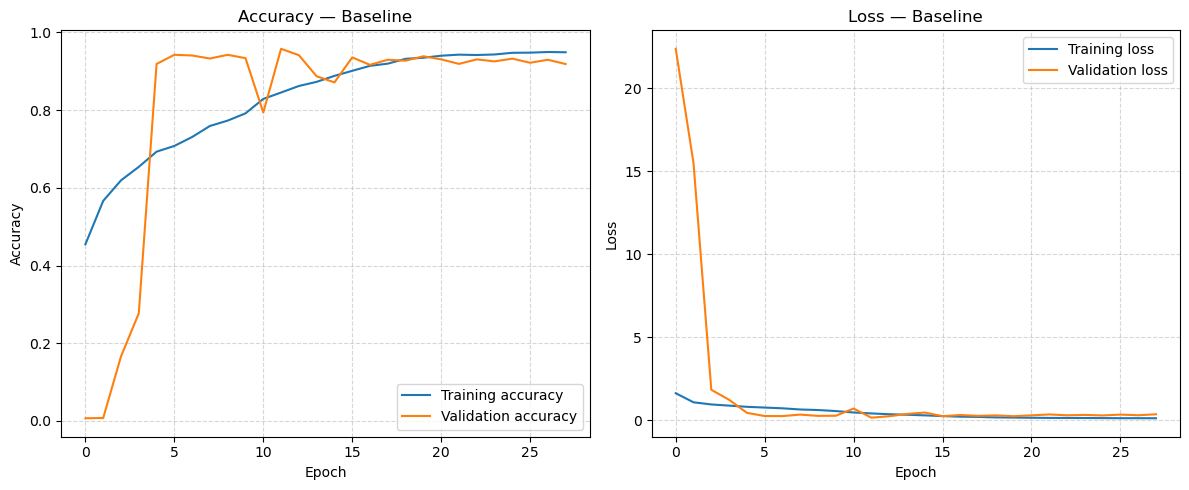

In [16]:
plot_training_history(history_baseline, baseline_name)

## He initialization

This experiment changes only the kernel initializer. All other training choices remain identical to the baseline.

In [17]:
set_global_determinism(SEED)

he_name = "He initialization"
he_checkpoint = CHECKPOINT_DIR / "he_initialization.weights.h5"

model_he = build_optimized_model(
    use_he=True,
    use_l2=False,
    optimizer="adam",
    input_shape=(*TARGET_SHAPE, 1),
    num_classes=num_classes,
)

history_he = model_he.fit(
    X_train,
    y_train_categorical,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_validation, y_validation_categorical),
    callbacks=make_macro_f1_callbacks(
        X_validation,
        y_validation,
        he_checkpoint,
        batch_size=PREDICTION_BATCH_SIZE,
    ),
    shuffle=True,
    verbose=1,
)

register_validation_result(
    he_name,
    model_he,
    history_he,
    he_checkpoint,
)

Epoch 1/50
124/125 [============================>.] - ETA: 0s - loss: 1.5693 - accuracy: 0.4945 — val_macro_f1: 0.0527 — val_balanced_accuracy: 0.2683
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 4s 27ms/step - loss: 1.5683 - accuracy: 0.4948 - val_loss: 2.1369 - val_accuracy: 0.0417 - val_macro_f1: 0.0527 - val_balanced_accuracy: 0.2683 - lr: 0.0010
Epoch 2/50
125/125 [==============================] - ETA: 0s - loss: 1.0134 - accuracy: 0.6157 — val_macro_f1: 0.1339 — val_balanced_accuracy: 0.3325
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 3s 25ms/step - loss: 1.0134 - accuracy: 0.6157 - val_loss: 2.3811 - val_accuracy: 0.0606 - val_macro_f1: 0.1339 - val_balanced_accuracy: 0.3325 - lr: 0.0010
Epoch 3/50
124/125 [============================>.] - ETA: 0s - loss: 0.8976 - accuracy: 0.6666 — val_macro_f1: 0.4260 — val_balanced_accuracy: 0.4287
Saved new best Macro F1 checkpoint at epoch 3.
125/12

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
He initialization,94.37%,80.81%,75.78%,80.81%,77.53%


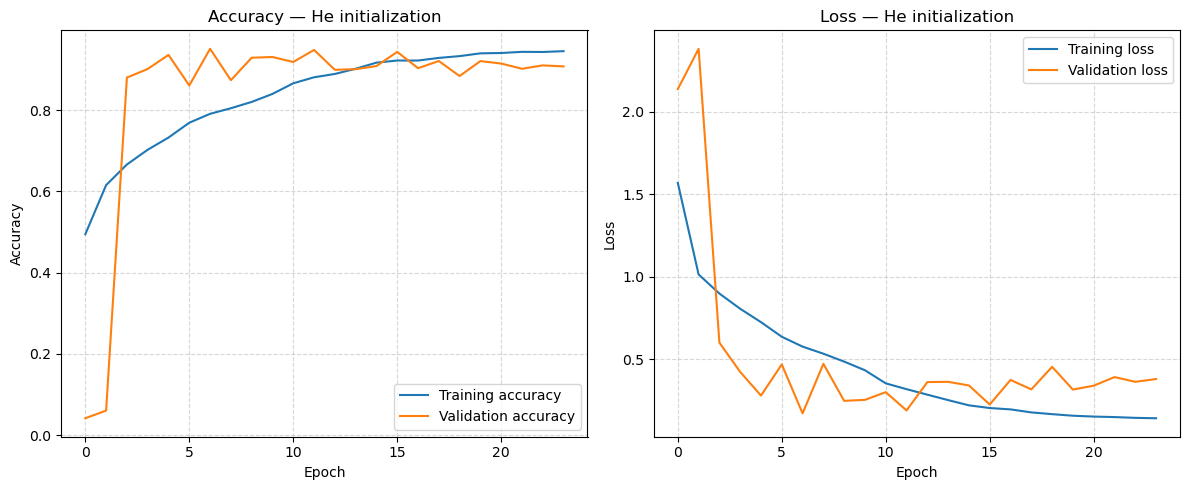

In [18]:
plot_training_history(history_he, he_name)

## Didactic experiment: arbitrary-angle rotations

Horizontal and vertical flips are combined with random rotations up to 72 degrees. This is intentionally retained as a problematic augmentation strategy.

The source maps contain discrete values. Arbitrary rotations require interpolation, which can introduce artificial intermediate values and blur narrow structures such as scratches. This experiment provides evidence for the report rather than a recommended preprocessing choice.

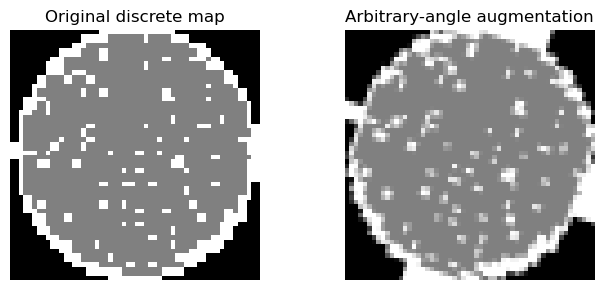

Original unique values: [0 1 2]
Augmented unique-value count: 678


In [19]:
set_global_determinism(SEED)

bad_augmentation = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=72,
)

preview_iterator = bad_augmentation.flow(
    X_train[:1],
    y_train_categorical[:1],
    batch_size=1,
    shuffle=False,
    seed=SEED,
)
preview_image = next(preview_iterator)[0][0]

_, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(np.squeeze(X_train[0]), cmap="gray")
axes[0].set_title("Original discrete map")
axes[1].imshow(np.squeeze(preview_image), cmap="gray")
axes[1].set_title("Arbitrary-angle augmentation")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

print(f"Original unique values: {np.unique(X_train[0])}")
print(
    "Augmented unique-value count: "
    f"{len(np.unique(preview_image))}"
)

In [20]:
set_global_determinism(SEED)

bad_rotation_name = "He + arbitrary rotations"
bad_rotation_checkpoint = (
    CHECKPOINT_DIR / "he_arbitrary_rotations.weights.h5"
)

model_bad_rotation = build_optimized_model(
    use_he=True,
    use_l2=False,
    optimizer="adam",
    input_shape=(*TARGET_SHAPE, 1),
    num_classes=num_classes,
)

bad_augmentation = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=72,
)

history_bad_rotation = model_bad_rotation.fit(
    bad_augmentation.flow(
        X_train,
        y_train_categorical,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    ),
    epochs=MAX_EPOCHS,
    validation_data=(X_validation, y_validation_categorical),
    callbacks=make_macro_f1_callbacks(
        X_validation,
        y_validation,
        bad_rotation_checkpoint,
        batch_size=PREDICTION_BATCH_SIZE,
    ),
    verbose=1,
)

register_validation_result(
    bad_rotation_name,
    model_bad_rotation,
    history_bad_rotation,
    bad_rotation_checkpoint,
)

Epoch 1/50
125/125 [==============================] - ETA: 0s - loss: 1.6406 - accuracy: 0.4659 — val_macro_f1: 0.0808 — val_balanced_accuracy: 0.2839
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 8s 62ms/step - loss: 1.6406 - accuracy: 0.4659 - val_loss: 2.2188 - val_accuracy: 0.0507 - val_macro_f1: 0.0808 - val_balanced_accuracy: 0.2839 - lr: 0.0010
Epoch 2/50
125/125 [==============================] - ETA: 0s - loss: 1.0239 - accuracy: 0.6119 — val_macro_f1: 0.3429 — val_balanced_accuracy: 0.4628
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 7s 60ms/step - loss: 1.0239 - accuracy: 0.6119 - val_loss: 1.4783 - val_accuracy: 0.1374 - val_macro_f1: 0.3429 - val_balanced_accuracy: 0.4628 - lr: 0.0010
Epoch 3/50
125/125 [==============================] - ETA: 0s - loss: 0.9195 - accuracy: 0.6605 — val_macro_f1: 0.5091 — val_balanced_accuracy: 0.4862
Saved new best Macro F1 checkpoint at epoch 3.
125/12

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
He + arbitrary rotations,82.91%,71.39%,64.93%,71.39%,64.95%


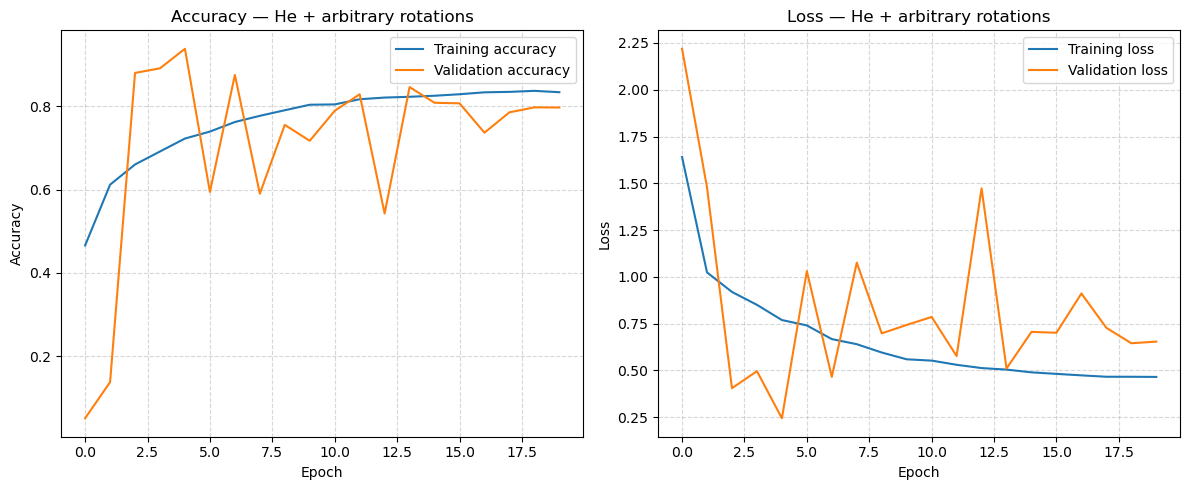

In [21]:
plot_training_history(
    history_bad_rotation,
    bad_rotation_name,
)

## Safe flip augmentation

This control experiment removes interpolated rotations while keeping horizontal and vertical flips. A flip changes spatial orientation without creating new pixel values.

In [22]:
set_global_determinism(SEED)

safe_flip_name = "He + safe flips"
safe_flip_checkpoint = CHECKPOINT_DIR / "he_safe_flips.weights.h5"

model_safe_flip = build_optimized_model(
    use_he=True,
    use_l2=False,
    optimizer="adam",
    input_shape=(*TARGET_SHAPE, 1),
    num_classes=num_classes,
)

safe_augmentation = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
)

history_safe_flip = model_safe_flip.fit(
    safe_augmentation.flow(
        X_train,
        y_train_categorical,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    ),
    epochs=MAX_EPOCHS,
    validation_data=(X_validation, y_validation_categorical),
    callbacks=make_macro_f1_callbacks(
        X_validation,
        y_validation,
        safe_flip_checkpoint,
        batch_size=PREDICTION_BATCH_SIZE,
    ),
    verbose=1,
)

register_validation_result(
    safe_flip_name,
    model_safe_flip,
    history_safe_flip,
    safe_flip_checkpoint,
)

Epoch 1/50
124/125 [============================>.] - ETA: 0s - loss: 1.5361 - accuracy: 0.5000 — val_macro_f1: 0.1351 — val_balanced_accuracy: 0.3885
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 5s 38ms/step - loss: 1.5318 - accuracy: 0.5005 - val_loss: 2.0141 - val_accuracy: 0.0609 - val_macro_f1: 0.1351 - val_balanced_accuracy: 0.3885 - lr: 0.0010
Epoch 2/50
122/125 [============================>.] - ETA: 0s - loss: 0.9588 - accuracy: 0.6455 — val_macro_f1: 0.2721 — val_balanced_accuracy: 0.3581
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 4s 35ms/step - loss: 0.9571 - accuracy: 0.6460 - val_loss: 1.7676 - val_accuracy: 0.2409 - val_macro_f1: 0.2721 - val_balanced_accuracy: 0.3581 - lr: 0.0010
Epoch 3/50
125/125 [==============================] - ETA: 0s - loss: 0.8570 - accuracy: 0.6894 — val_macro_f1: 0.5111 — val_balanced_accuracy: 0.5769
Saved new best Macro F1 checkpoint at epoch 3.
125/12

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
He + safe flips,94.06%,84.49%,74.47%,84.49%,78.42%


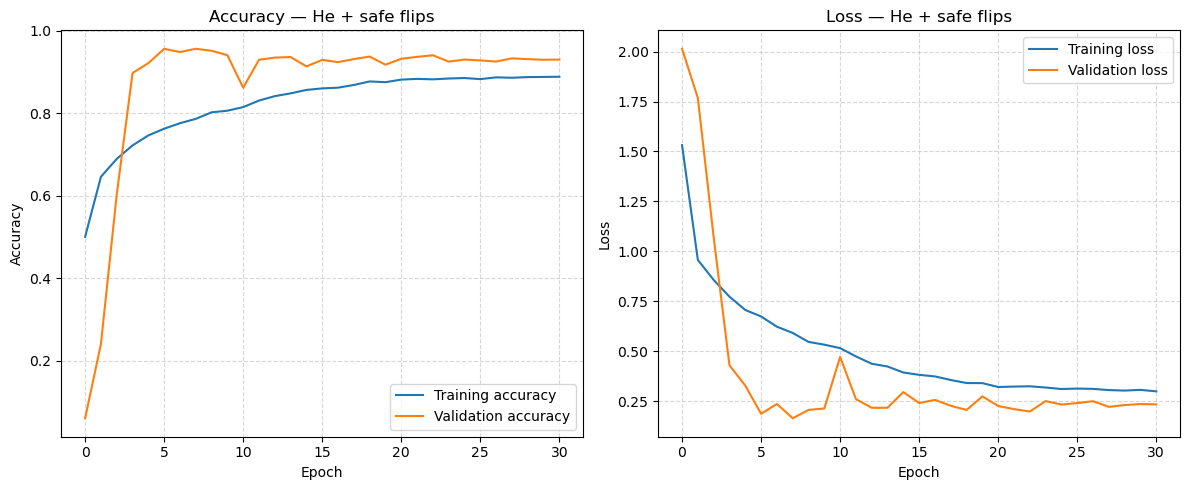

In [23]:
plot_training_history(
    history_safe_flip,
    safe_flip_name,
)

## Safe augmentation with L2 regularization

The regularized architecture combines He initialization, safe flips, and an L2 penalty on convolutional and dense kernels.

In [24]:
set_global_determinism(SEED)

regularized_name = "He + safe flips + L2"
regularized_checkpoint = (
    CHECKPOINT_DIR / "he_safe_flips_l2.weights.h5"
)

model_regularized = build_optimized_model(
    use_he=True,
    use_l2=True,
    optimizer="adam",
    input_shape=(*TARGET_SHAPE, 1),
    num_classes=num_classes,
)

safe_augmentation = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
)

history_regularized = model_regularized.fit(
    safe_augmentation.flow(
        X_train,
        y_train_categorical,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    ),
    epochs=MAX_EPOCHS,
    validation_data=(X_validation, y_validation_categorical),
    callbacks=make_macro_f1_callbacks(
        X_validation,
        y_validation,
        regularized_checkpoint,
        batch_size=PREDICTION_BATCH_SIZE,
    ),
    verbose=1,
)

register_validation_result(
    regularized_name,
    model_regularized,
    history_regularized,
    regularized_checkpoint,
)

Epoch 1/50
125/125 [==============================] - ETA: 0s - loss: 2.2158 - accuracy: 0.4993 — val_macro_f1: 0.0854 — val_balanced_accuracy: 0.2621
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 6s 44ms/step - loss: 2.2158 - accuracy: 0.4993 - val_loss: 2.7188 - val_accuracy: 0.0570 - val_macro_f1: 0.0854 - val_balanced_accuracy: 0.2621 - lr: 0.0010
Epoch 2/50
124/125 [============================>.] - ETA: 0s - loss: 1.5837 - accuracy: 0.6401 — val_macro_f1: 0.2371 — val_balanced_accuracy: 0.3088
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 5s 39ms/step - loss: 1.5831 - accuracy: 0.6398 - val_loss: 1.9778 - val_accuracy: 0.2576 - val_macro_f1: 0.2371 - val_balanced_accuracy: 0.3088 - lr: 0.0010
Epoch 3/50
125/125 [==============================] - ETA: 0s - loss: 1.4047 - accuracy: 0.6871 — val_macro_f1: 0.4670 — val_balanced_accuracy: 0.4966
Saved new best Macro F1 checkpoint at epoch 3.
125/12

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
He + safe flips + L2,94.88%,91.77%,78.35%,91.77%,83.82%


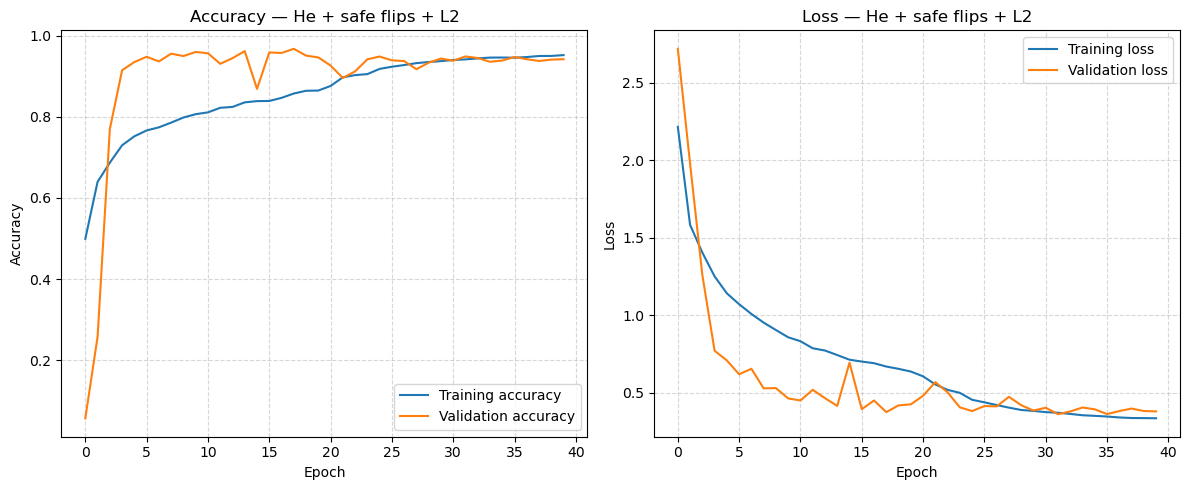

In [25]:
plot_training_history(
    history_regularized,
    regularized_name,
)

## Architecture comparison on validation data

Macro F1 is the primary comparison metric because each class contributes equally. Balanced accuracy is used as a secondary measure. Ordinary accuracy remains visible but is not used to choose a configuration.

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,,
He + safe flips + L2,94.88%,91.77%,78.35%,91.77%,83.82%
Baseline,93.86%,83.27%,75.96%,83.27%,78.48%
He + safe flips,94.06%,84.49%,74.47%,84.49%,78.42%
He initialization,94.37%,80.81%,75.78%,80.81%,77.53%
He + arbitrary rotations,82.91%,71.39%,64.93%,71.39%,64.95%


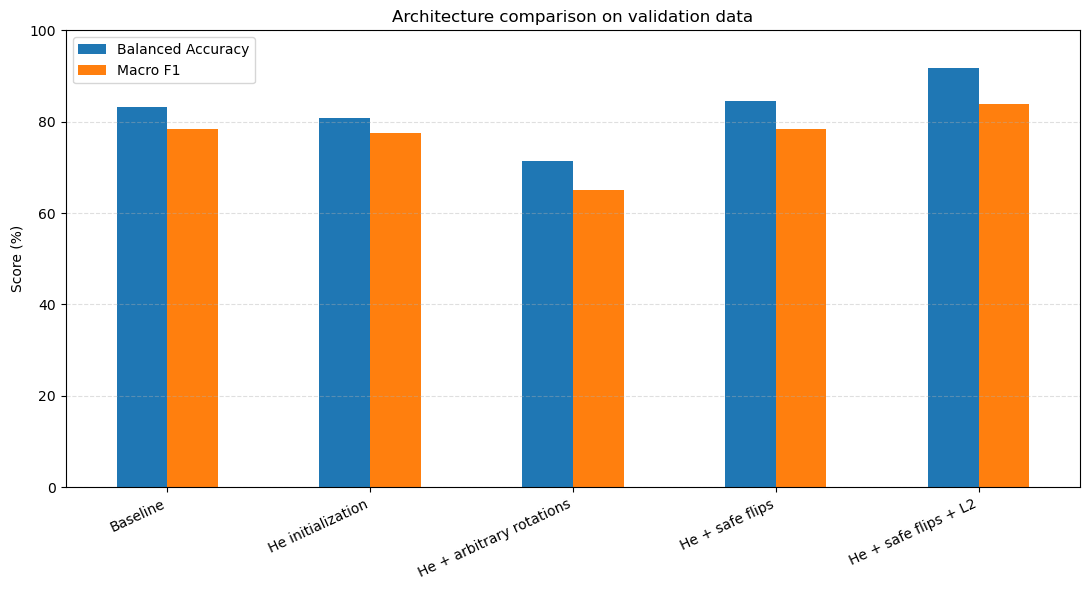

In [26]:
validation_df = (
    pd.DataFrame(validation_records)
    .set_index("Model")
    .sort_values(
        ["Macro F1", "Balanced Accuracy"],
        ascending=False,
    )
)

display(
    validation_df.style.format(
        {
            column: "{:.2%}"
            for column in validation_df.columns
        }
    )
)

architecture_names = [
    baseline_name,
    he_name,
    bad_rotation_name,
    safe_flip_name,
    regularized_name,
]
architecture_validation_df = validation_df.loc[
    architecture_names
]

axis = (
    architecture_validation_df[
        ["Balanced Accuracy", "Macro F1"]
    ]
    .mul(100)
    .plot(kind="bar", figsize=(11, 6))
)
axis.set_title("Architecture comparison on validation data")
axis.set_ylabel("Score (%)")
axis.set_xlabel("")
axis.set_ylim(0, 100)
axis.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Optimizer comparison

The optimizer study uses the same regularized architecture and safe augmentation for every run. Each optimizer receives a fresh model initialized from the same seed.

In [27]:
optimizer_factories = {
    "SGD + Nesterov": lambda: SGD(
        learning_rate=0.01,
        momentum=0.9,
        nesterov=True,
    ),
    "RMSprop": lambda: RMSprop(learning_rate=0.001),
    "Nadam": lambda: Nadam(learning_rate=0.001),
}

optimizer_model_names = [regularized_name]

optimizer_histories = {
    "Adam": history_regularized,
}

for optimizer_name, optimizer_factory in optimizer_factories.items():
    set_global_determinism(SEED)

    model_name = f"Optimizer study — {optimizer_name}"
    safe_filename = (
        optimizer_name.lower()
        .replace(" + ", "_")
        .replace(" ", "_")
    )
    checkpoint_path = (
        CHECKPOINT_DIR
        / f"optimizer_{safe_filename}.weights.h5"
    )

    model = build_optimized_model(
        use_he=True,
        use_l2=True,
        optimizer=optimizer_factory(),
        input_shape=(*TARGET_SHAPE, 1),
        num_classes=num_classes,
    )

    safe_augmentation = ImageDataGenerator(
        horizontal_flip=True,
        vertical_flip=True,
    )

    history = model.fit(
        safe_augmentation.flow(
            X_train,
            y_train_categorical,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED,
        ),
        epochs=MAX_EPOCHS,
        validation_data=(
            X_validation,
            y_validation_categorical,
        ),
        callbacks=make_macro_f1_callbacks(
            X_validation,
            y_validation,
            checkpoint_path,
            batch_size=PREDICTION_BATCH_SIZE,
        ),
        verbose=1,
    )

    register_validation_result(
        model_name,
        model,
        history,
        checkpoint_path,
    )

    optimizer_model_names.append(model_name)
    optimizer_histories[optimizer_name] = history

Epoch 1/50
124/125 [============================>.] - ETA: 0s - loss: 2.3990 - accuracy: 0.4396 — val_macro_f1: 0.0875 — val_balanced_accuracy: 0.2360
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 6s 48ms/step - loss: 2.3942 - accuracy: 0.4407 - val_loss: 2.8574 - val_accuracy: 0.0522 - val_macro_f1: 0.0875 - val_balanced_accuracy: 0.2360 - lr: 0.0100
Epoch 2/50
125/125 [==============================] - ETA: 0s - loss: 1.8645 - accuracy: 0.5439 — val_macro_f1: 0.2963 — val_balanced_accuracy: 0.3648
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 5s 42ms/step - loss: 1.8645 - accuracy: 0.5439 - val_loss: 2.1068 - val_accuracy: 0.4292 - val_macro_f1: 0.2963 - val_balanced_accuracy: 0.3648 - lr: 0.0100
Epoch 3/50
123/125 [============================>.] - ETA: 0s - loss: 1.7396 - accuracy: 0.5853 — val_macro_f1: 0.3670 — val_balanced_accuracy: 0.4311
Saved new best Macro F1 checkpoint at epoch 3.
125/12

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Optimizer study — SGD + Nesterov,95.84%,90.46%,81.36%,90.46%,85.28%


Epoch 1/50
123/125 [============================>.] - ETA: 0s - loss: 2.6663 - accuracy: 0.4801 — val_macro_f1: 0.1359 — val_balanced_accuracy: 0.2889
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 5s 39ms/step - loss: 2.6513 - accuracy: 0.4818 - val_loss: 2.4107 - val_accuracy: 0.0607 - val_macro_f1: 0.1359 - val_balanced_accuracy: 0.2889 - lr: 0.0010
Epoch 2/50
125/125 [==============================] - ETA: 0s - loss: 1.4836 - accuracy: 0.6551 — val_macro_f1: 0.3637 — val_balanced_accuracy: 0.4885
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 5s 37ms/step - loss: 1.4836 - accuracy: 0.6551 - val_loss: 4.6728 - val_accuracy: 0.0658 - val_macro_f1: 0.3637 - val_balanced_accuracy: 0.4885 - lr: 0.0010
Epoch 3/50
124/125 [============================>.] - ETA: 0s - loss: 1.2173 - accuracy: 0.7389 — val_macro_f1: 0.4287 — val_balanced_accuracy: 0.5105
Saved new best Macro F1 checkpoint at epoch 3.
125/12

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Optimizer study — RMSprop,95.60%,89.24%,81.02%,89.24%,84.37%


Epoch 1/50
125/125 [==============================] - ETA: 0s - loss: 2.1019 - accuracy: 0.5240 — val_macro_f1: 0.0957 — val_balanced_accuracy: 0.3305
Saved new best Macro F1 checkpoint at epoch 1.
125/125 [==============================] - 5s 38ms/step - loss: 2.1019 - accuracy: 0.5240 - val_loss: 2.8273 - val_accuracy: 0.0511 - val_macro_f1: 0.0957 - val_balanced_accuracy: 0.3305 - lr: 0.0010
Epoch 2/50
122/125 [============================>.] - ETA: 0s - loss: 1.4847 - accuracy: 0.6743 — val_macro_f1: 0.3584 — val_balanced_accuracy: 0.4779
Saved new best Macro F1 checkpoint at epoch 2.
125/125 [==============================] - 4s 35ms/step - loss: 1.4839 - accuracy: 0.6744 - val_loss: 2.9746 - val_accuracy: 0.0543 - val_macro_f1: 0.3584 - val_balanced_accuracy: 0.4779 - lr: 0.0010
Epoch 3/50
123/125 [============================>.] - ETA: 0s - loss: 1.3206 - accuracy: 0.7239 — val_macro_f1: 0.4513 — val_balanced_accuracy: 0.4912
Saved new best Macro F1 checkpoint at epoch 3.
125/12

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Optimizer study — Nadam,96.01%,90.48%,81.77%,90.48%,85.64%


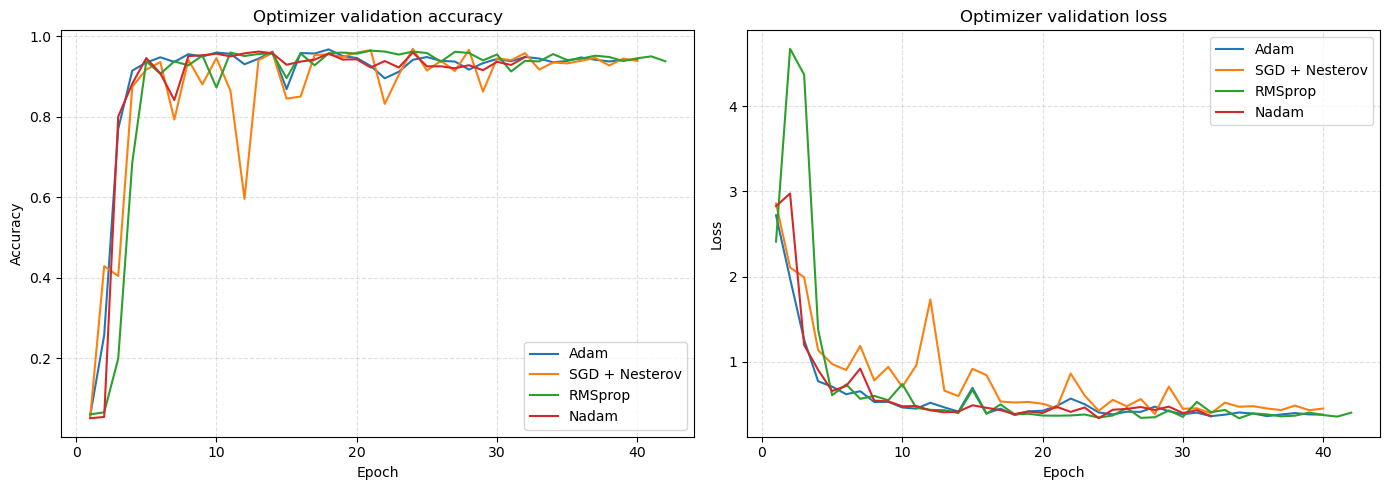

In [28]:
_, axes = plt.subplots(1, 2, figsize=(14, 5))

for optimizer_name, history in optimizer_histories.items():
    epochs = range(
        1,
        len(history.history["val_accuracy"]) + 1,
    )
    axes[0].plot(
        epochs,
        history.history["val_accuracy"],
        label=optimizer_name,
    )
    axes[1].plot(
        epochs,
        history.history["val_loss"],
        label=optimizer_name,
    )

axes[0].set_title("Optimizer validation accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")

axes[1].set_title("Optimizer validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")

for axis in axes:
    axis.legend()
    axis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [29]:
validation_df = (
    pd.DataFrame(validation_records)
    .drop_duplicates(subset="Model", keep="last")
    .set_index("Model")
    .sort_values(
        ["Macro F1", "Balanced Accuracy"],
        ascending=False,
    )
)

optimizer_validation_df = validation_df.loc[
    optimizer_model_names
]
display(
    optimizer_validation_df.style.format(
        {
            column: "{:.2%}"
            for column in optimizer_validation_df.columns
        }
    )
)

selected_model_name = validation_df.index[0]
print(
    "Model selected from validation metrics: "
    f"{selected_model_name}"
)

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,,
He + safe flips + L2,94.88%,91.77%,78.35%,91.77%,83.82%
Optimizer study — SGD + Nesterov,95.84%,90.46%,81.36%,90.46%,85.28%
Optimizer study — RMSprop,95.60%,89.24%,81.02%,89.24%,84.37%
Optimizer study — Nadam,96.01%,90.48%,81.77%,90.48%,85.64%


Model selected from validation metrics: Optimizer study — Nadam


## Final evaluation on the large test set

All configurations are now fixed. Every saved checkpoint is evaluated on the same uncapped 20% test partition.

These results must not be used to redesign or retrain the models. Any later tuning would require a new untouched test set.

In [30]:
test_records = []
test_reports = {}
test_confusion_matrices = {}
test_predictions = {}

for model_name, model in models.items():
    model.load_weights(checkpoints[model_name])

    metrics, report, matrix, predictions = evaluate_classifier(
        model,
        X_test,
        y_test,
        class_names,
        batch_size=PREDICTION_BATCH_SIZE,
    )

    test_records.append({"Model": model_name, **metrics})
    test_reports[model_name] = report
    test_confusion_matrices[model_name] = matrix
    test_predictions[model_name] = predictions

test_df = (
    pd.DataFrame(test_records)
    .set_index("Model")
    .loc[validation_df.index]
)

display(
    test_df.style.format(
        {
            column: "{:.2%}"
            for column in test_df.columns
        }
    )
)

,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,,
Optimizer study — Nadam,95.68%,87.32%,79.91%,87.32%,83.14%
Optimizer study — SGD + Nesterov,95.39%,85.09%,79.88%,85.09%,81.51%
Optimizer study — RMSprop,95.51%,87.33%,81.16%,87.33%,83.52%
He + safe flips + L2,94.67%,88.18%,77.50%,88.18%,81.56%
Baseline,93.71%,79.75%,74.00%,79.75%,75.72%
He + safe flips,93.81%,81.19%,73.86%,81.19%,76.34%
He initialization,94.06%,78.57%,73.46%,78.57%,75.25%
He + arbitrary rotations,82.93%,68.61%,63.71%,68.61%,62.61%


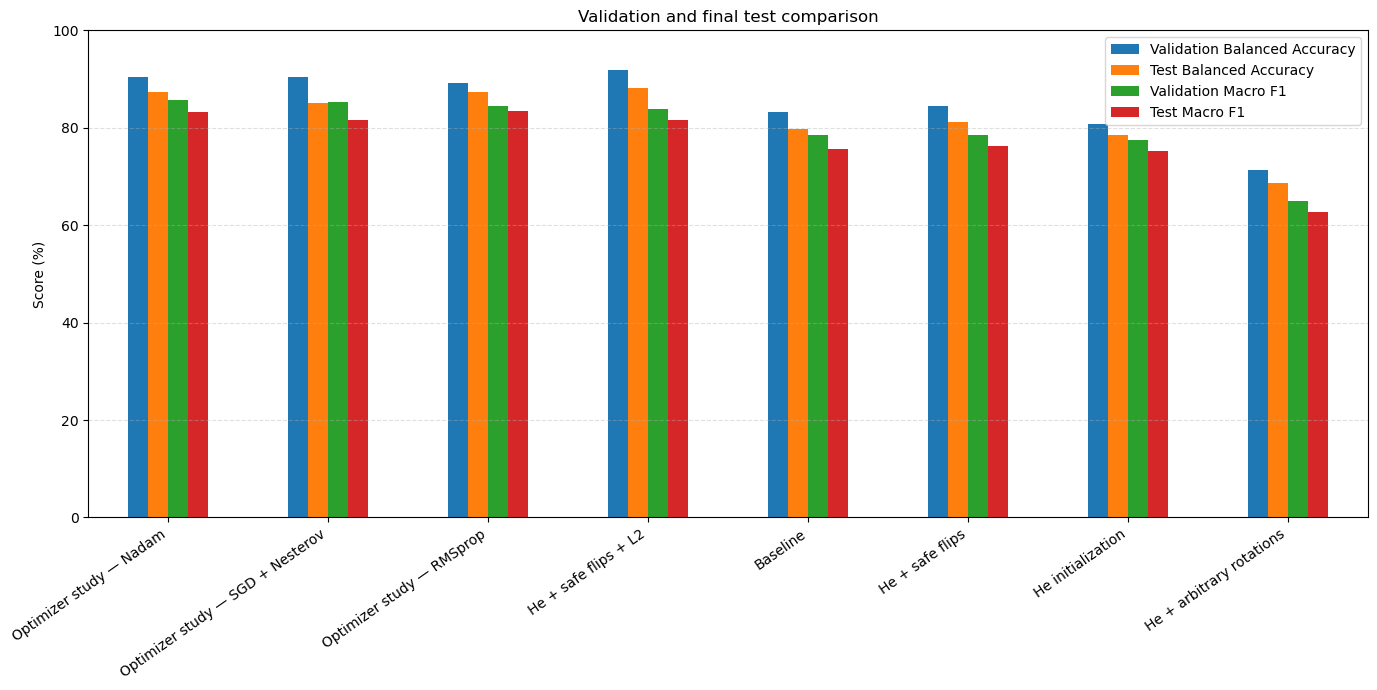

In [31]:
comparison = pd.concat(
    {
        "Validation Balanced Accuracy": (
            validation_df["Balanced Accuracy"]
        ),
        "Test Balanced Accuracy": (
            test_df["Balanced Accuracy"]
        ),
        "Validation Macro F1": validation_df["Macro F1"],
        "Test Macro F1": test_df["Macro F1"],
    },
    axis=1,
)

axis = comparison.mul(100).plot(
    kind="bar",
    figsize=(14, 7),
)
axis.set_title("Validation and final test comparison")
axis.set_ylabel("Score (%)")
axis.set_xlabel("")
axis.set_ylim(0, 100)
axis.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Detailed report for the validation-selected model

The detailed test report is shown for the model chosen before opening the test results.

Validation-selected model: Optimizer study — Nadam


,precision,recall,f1-score,support
center,0.803,0.962,0.875,859
donut,0.835,0.865,0.850,111
edge-loc,0.670,0.847,0.748,1038
edge-ring,0.970,0.971,0.970,1936
loc,0.568,0.788,0.660,718
near-full,0.931,0.900,0.915,30
none,0.993,0.967,0.980,29486
random,0.856,0.861,0.859,173
scratch,0.566,0.699,0.625,239
accuracy,0.957,0.957,0.957,1


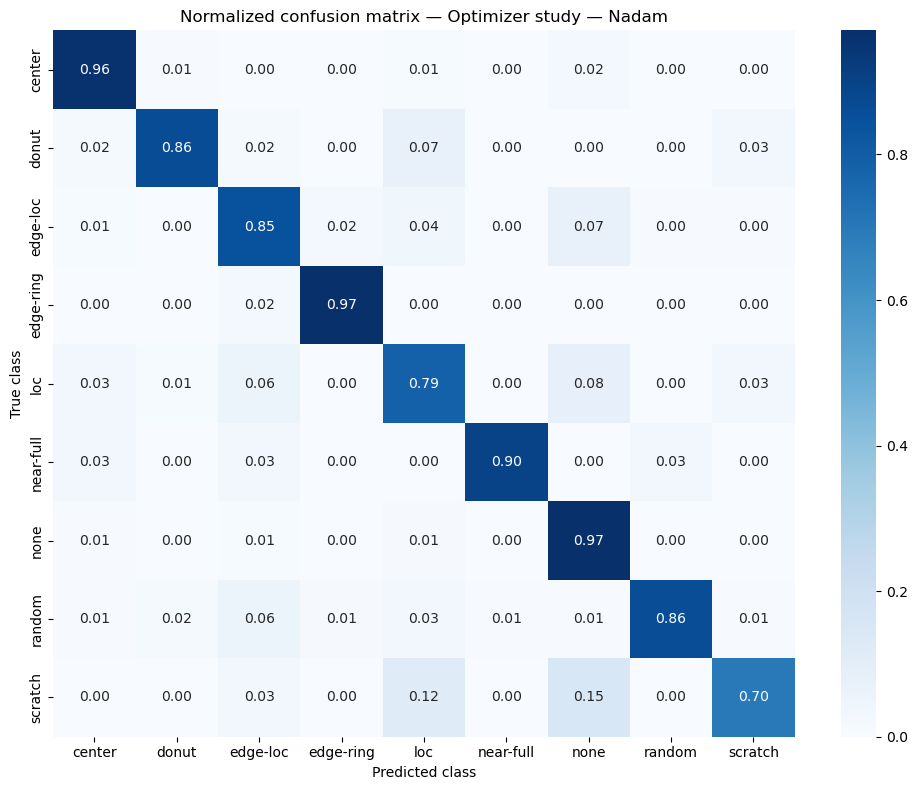

In [46]:
print(f"Validation-selected model: {selected_model_name}")

display(
    test_reports[selected_model_name]
    .loc[
        list(class_names)
        + ["accuracy", "macro avg", "weighted avg"]
    ]
    .style.format(
        {
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "f1-score": "{:.3f}",
            "support": "{:.0f}",
        }
    )
)

plot_confusion_matrix(
    test_confusion_matrices[selected_model_name],
    class_names,
    title=(
        "Normalized confusion matrix — "
        f"{selected_model_name}"
    ),
    normalize=True,
)

## Feature-map inspection

The selected model is inspected on one example from the untouched test partition after final evaluation.

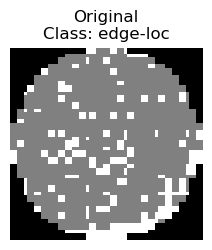

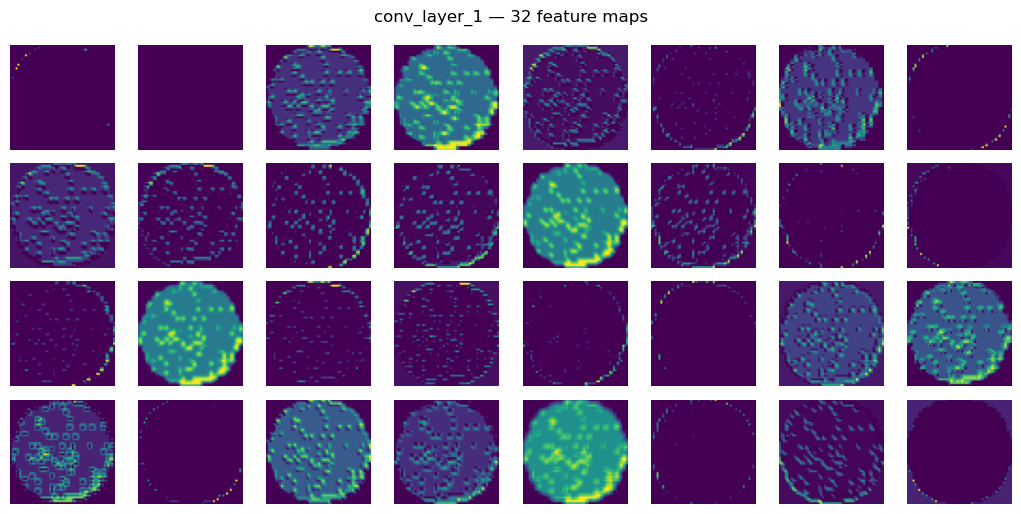

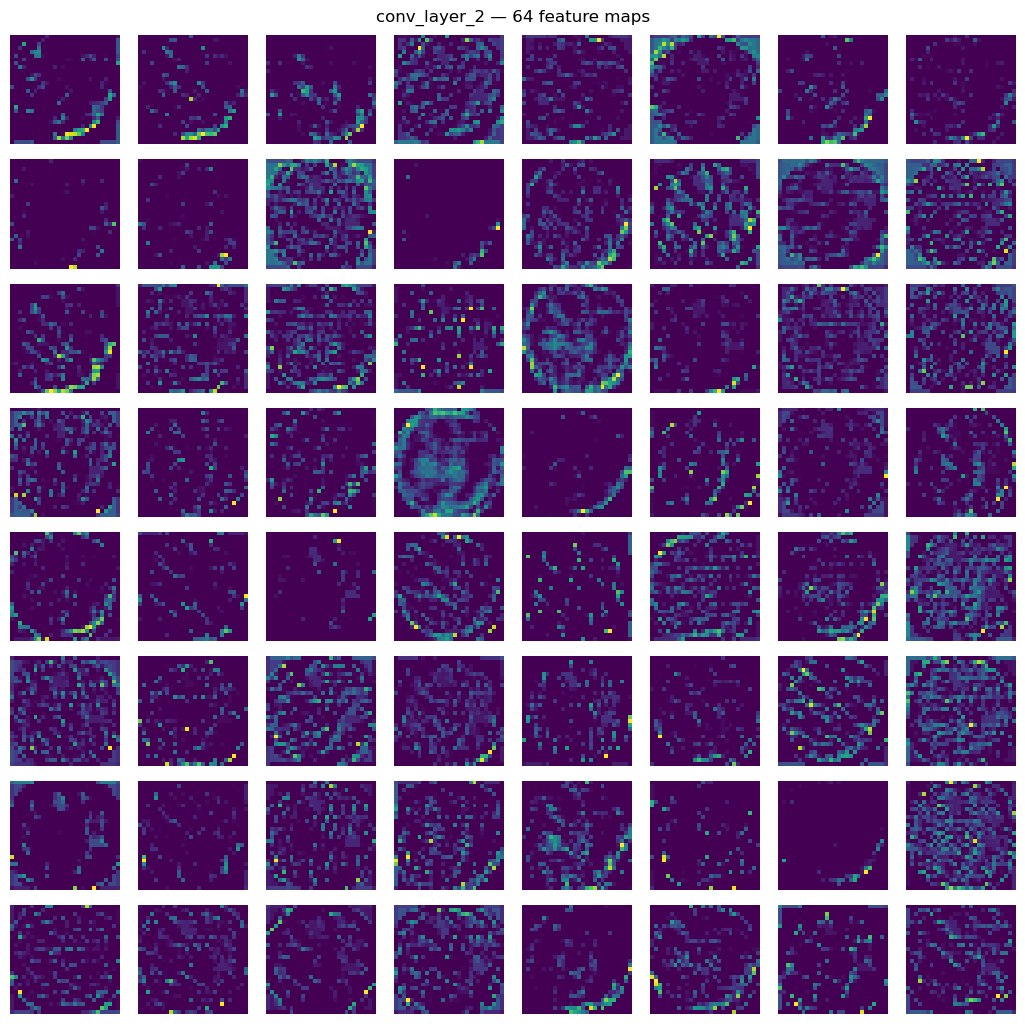

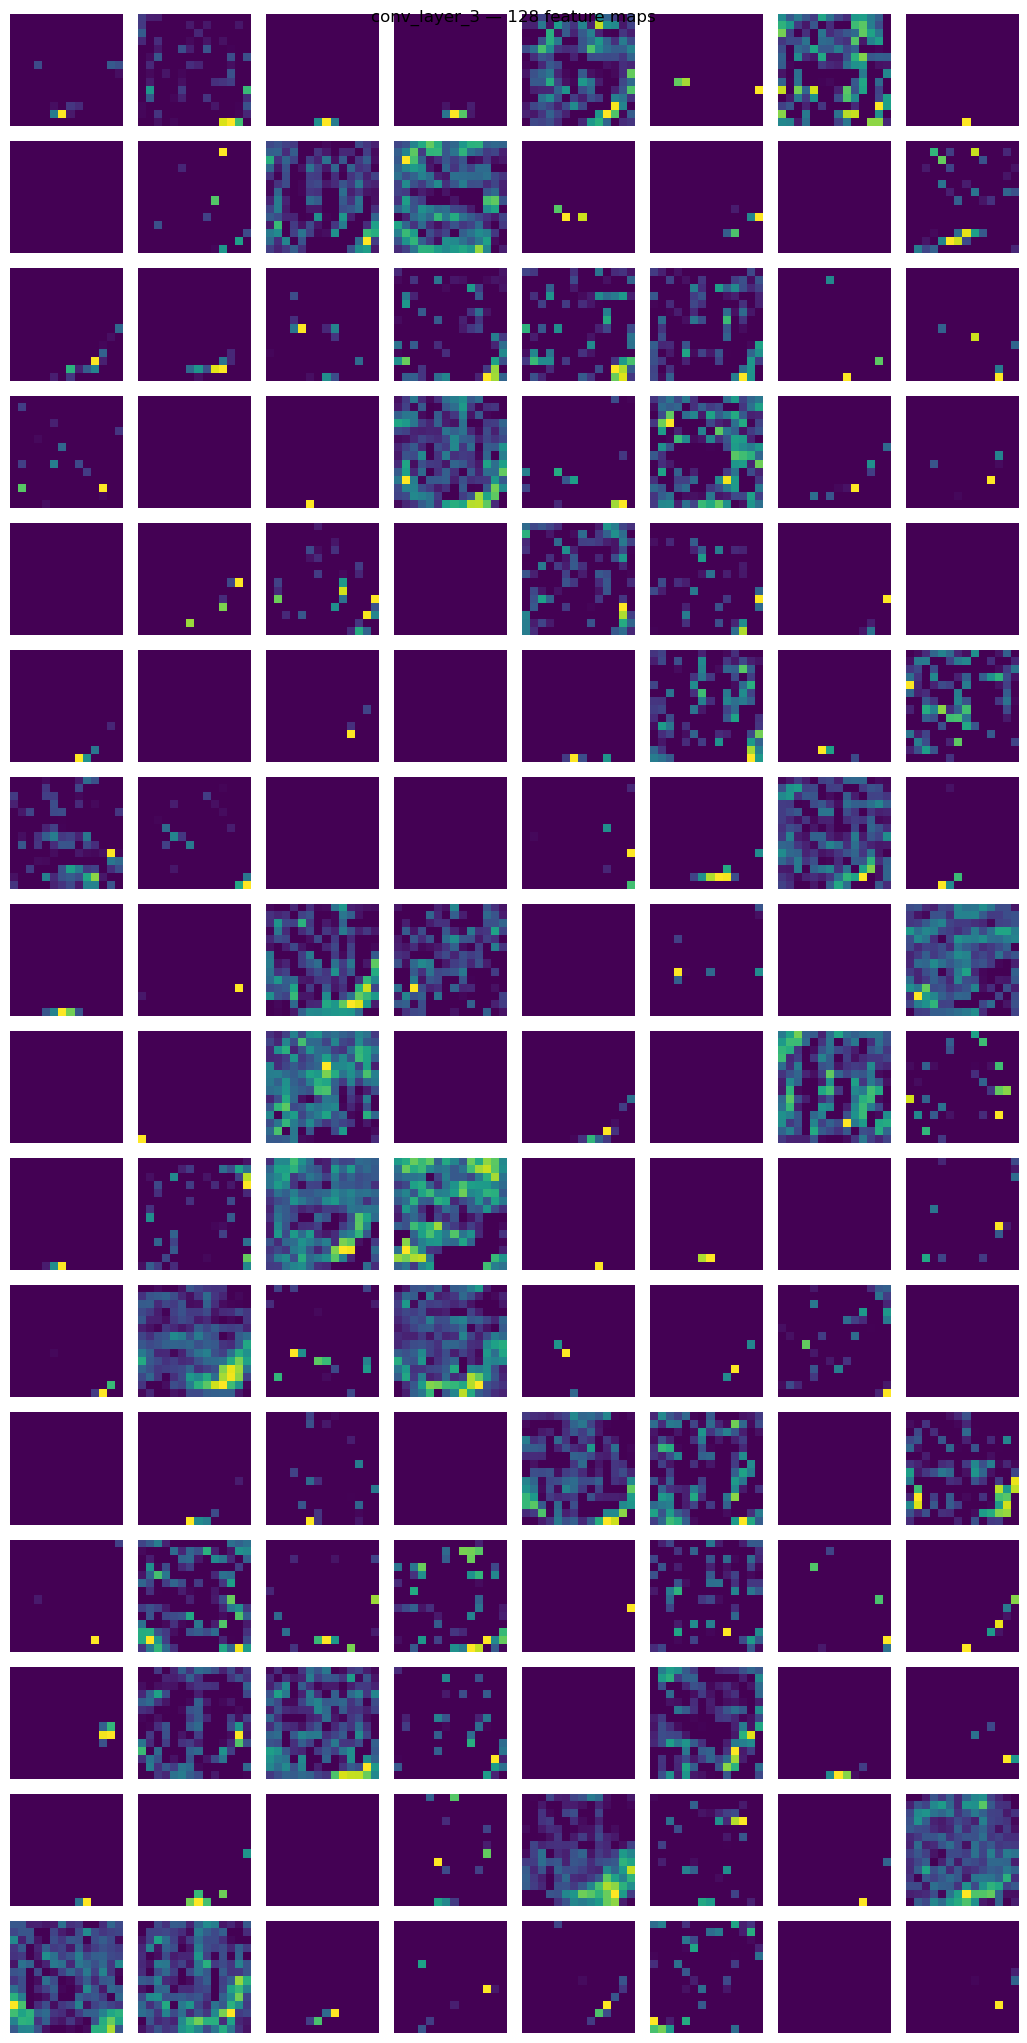

In [33]:
sample_index = 12

visualize_original_and_maps(
    models[selected_model_name],
    X_test[sample_index],
    int(y_test[sample_index]),
    class_names,
)

## Saved outputs

The split indices make the exact data partition reproducible. Validation and test tables are exported for direct use in the report.

In [34]:
validation_df.to_csv(
    OUTPUT_DIR / "validation_results.csv"
)
test_df.to_csv(
    OUTPUT_DIR / "large_test_results.csv"
)
split_distribution.to_csv(
    OUTPUT_DIR / "split_distribution.csv"
)

print(f"Saved outputs under: {OUTPUT_DIR.resolve()}")

Saved outputs under: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\project\cnn_outputs


## Convolutional filter activity analysis

The following analysis measures how often each convolutional filter produces a positive activation on validation samples.

A dark feature map for a single wafer does not imply that a filter is useless. Some filters may be specialized for rare failure classes. For this reason, filter activity is first measured globally and then separately for every class.

This analysis measures activation frequency, not predictive importance. The final evidence for reducing the number of filters must come from a controlled comparison between the full and intermediate models.

In [35]:
def analyze_conv_filter_activity(
    model,
    features,
    max_samples=4096,
    batch_size=128,
    threshold=1e-6,
    seed=42,
):
    """
    Measure the activity of every Conv2D filter.

    A filter is considered active for a sample when at least one spatial
    activation is greater than the selected threshold.
    """
    if len(features) == 0:
        raise ValueError("The supplied feature array is empty.")

    convolutional_layers = [
        layer
        for layer in model.layers
        if isinstance(layer, tf.keras.layers.Conv2D)
    ]

    if not convolutional_layers:
        raise ValueError("The model does not contain Conv2D layers.")

    sample_count = min(max_samples, len(features))
    random_generator = np.random.default_rng(seed)

    if sample_count < len(features):
        sample_indices = random_generator.choice(
            len(features),
            size=sample_count,
            replace=False,
        )
    else:
        sample_indices = np.arange(len(features))

    sampled_features = features[sample_indices]

    activation_model = tf.keras.Model(
        inputs=model.input,
        outputs=[
            layer.output
            for layer in convolutional_layers
        ],
    )

    accumulators = {}

    for layer in convolutional_layers:
        filter_count = layer.filters

        accumulators[layer.name] = {
            "active_samples": np.zeros(
                filter_count,
                dtype=np.float64,
            ),
            "active_positions": np.zeros(
                filter_count,
                dtype=np.float64,
            ),
            "activation_sum": np.zeros(
                filter_count,
                dtype=np.float64,
            ),
            "peak_activation": np.zeros(
                filter_count,
                dtype=np.float64,
            ),
            "total_positions": 0,
        }

    processed_samples = 0

    for start_index in range(
        0,
        sample_count,
        batch_size,
    ):
        batch = sampled_features[
            start_index:start_index + batch_size
        ]

        layer_outputs = activation_model.predict(
            batch,
            batch_size=len(batch),
            verbose=0,
        )

        if not isinstance(layer_outputs, list):
            layer_outputs = [layer_outputs]

        for layer, activations in zip(
            convolutional_layers,
            layer_outputs,
        ):
            accumulator = accumulators[layer.name]

            positive_activations = (
                activations > threshold
            )

            sample_is_active = positive_activations.any(
                axis=(1, 2)
            )

            accumulator["active_samples"] += (
                sample_is_active.sum(axis=0)
            )

            accumulator["active_positions"] += (
                positive_activations.sum(
                    axis=(0, 1, 2)
                )
            )

            accumulator["activation_sum"] += (
                activations.sum(axis=(0, 1, 2))
            )

            accumulator["peak_activation"] = np.maximum(
                accumulator["peak_activation"],
                activations.max(axis=(0, 1, 2)),
            )

            accumulator["total_positions"] += (
                activations.shape[0]
                * activations.shape[1]
                * activations.shape[2]
            )

        processed_samples += len(batch)

    rows = []

    for layer in convolutional_layers:
        accumulator = accumulators[layer.name]

        for filter_index in range(layer.filters):
            rows.append(
                {
                    "Layer": layer.name,
                    "Filter": filter_index,
                    "Sample activity rate": (
                        accumulator["active_samples"][
                            filter_index
                        ]
                        / processed_samples
                    ),
                    "Mean spatial activity": (
                        accumulator["active_positions"][
                            filter_index
                        ]
                        / accumulator["total_positions"]
                    ),
                    "Mean activation": (
                        accumulator["activation_sum"][
                            filter_index
                        ]
                        / accumulator["total_positions"]
                    ),
                    "Peak activation": (
                        accumulator["peak_activation"][
                            filter_index
                        ]
                    ),
                    "Analyzed samples": processed_samples,
                }
            )

    return pd.DataFrame(rows)

In [36]:
selected_model = models[selected_model_name]

selected_model.load_weights(
    checkpoints[selected_model_name]
)

GLOBAL_ACTIVITY_THRESHOLD = 1e-6
GLOBAL_ACTIVITY_SAMPLES = min(
    4096,
    len(X_validation),
)

filter_activity = analyze_conv_filter_activity(
    model=selected_model,
    features=X_validation,
    max_samples=GLOBAL_ACTIVITY_SAMPLES,
    batch_size=128,
    threshold=GLOBAL_ACTIVITY_THRESHOLD,
    seed=SEED,
)


def assign_activity_status(row):
    if row["Peak activation"] <= GLOBAL_ACTIVITY_THRESHOLD:
        return "Inactive in sampled validation"

    if row["Sample activity rate"] <= 0.001:
        return "Almost inactive"

    if row["Sample activity rate"] <= 0.01:
        return "Very rarely active"

    if row["Sample activity rate"] <= 0.05:
        return "Specialized or rarely active"

    return "Frequently active"


filter_activity["Status"] = filter_activity.apply(
    assign_activity_status,
    axis=1,
)

activity_status_order = [
    "Inactive in sampled validation",
    "Almost inactive",
    "Very rarely active",
    "Specialized or rarely active",
    "Frequently active",
]

filter_activity["Status"] = pd.Categorical(
    filter_activity["Status"],
    categories=activity_status_order,
    ordered=True,
)

activity_summary = pd.crosstab(
    filter_activity["Layer"],
    filter_activity["Status"],
).reindex(
    columns=activity_status_order,
    fill_value=0,
)

print(
    "Validation samples analyzed:",
    GLOBAL_ACTIVITY_SAMPLES,
)

display(activity_summary)

display(
    filter_activity.sort_values(
        [
            "Sample activity rate",
            "Mean spatial activity",
        ]
    ).head(40).style.format(
        {
            "Sample activity rate": "{:.3%}",
            "Mean spatial activity": "{:.3%}",
            "Mean activation": "{:.6f}",
            "Peak activation": "{:.6f}",
        }
    )
)

Validation samples analyzed: 4096


Status,Inactive in sampled validation,Almost inactive,Very rarely active,Specialized or rarely active,Frequently active
Layer,,,,,
conv_layer_1,1,0,0,0,31
conv_layer_2,0,0,0,0,64
conv_layer_3,9,3,2,1,113


,Layer,Filter,Sample activity rate,Mean spatial activity,Mean activation,Peak activation,Analyzed samples,Status
1,conv_layer_1,1,0.000%,0.000%,0.000000,0.000000,4096,Inactive in sampled validation
110,conv_layer_3,14,0.000%,0.000%,0.000000,-0.000000,4096,Inactive in sampled validation
121,conv_layer_3,25,0.000%,0.000%,0.000000,-0.000000,4096,Inactive in sampled validation
131,conv_layer_3,35,0.000%,0.000%,0.000000,-0.000000,4096,Inactive in sampled validation
139,conv_layer_3,43,0.000%,0.000%,0.000000,-0.000000,4096,Inactive in sampled validation
165,conv_layer_3,69,0.000%,0.000%,0.000000,-0.000000,4096,Inactive in sampled validation
187,conv_layer_3,91,0.000%,0.000%,0.000000,-0.000000,4096,Inactive in sampled validation
204,conv_layer_3,108,0.000%,0.000%,0.000000,-0.000000,4096,Inactive in sampled validation
210,conv_layer_3,114,0.000%,0.000%,0.000000,-0.000000,4096,Inactive in sampled validation
222,conv_layer_3,126,0.000%,0.000%,0.000000,-0.000000,4096,Inactive in sampled validation


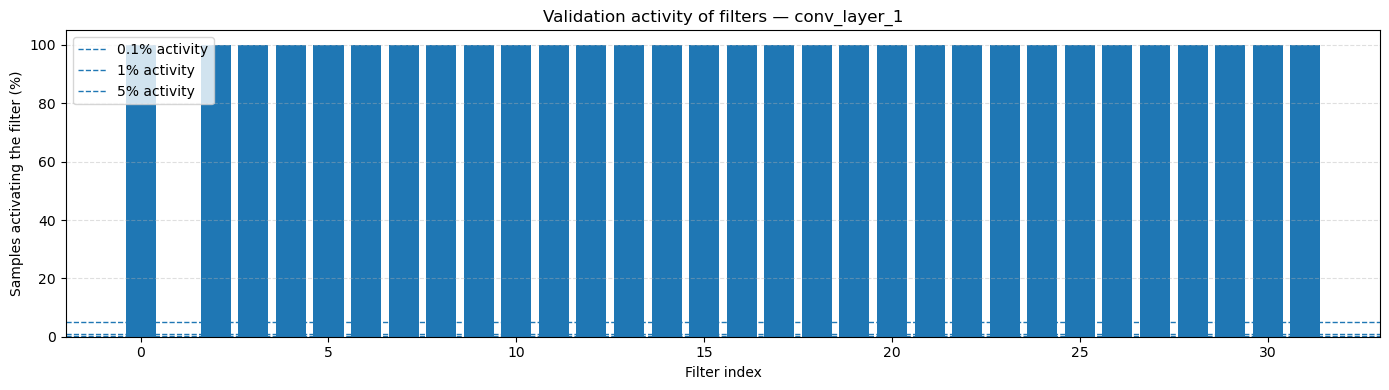

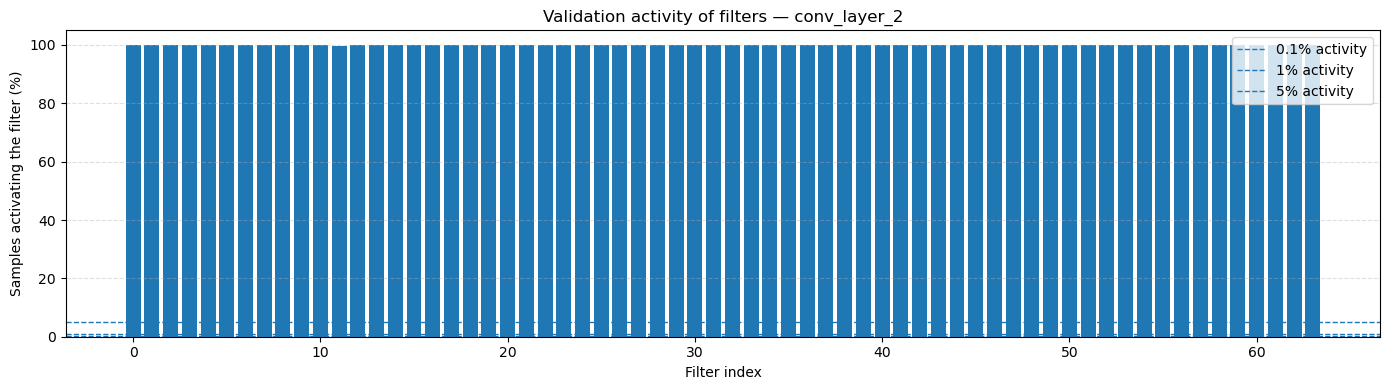

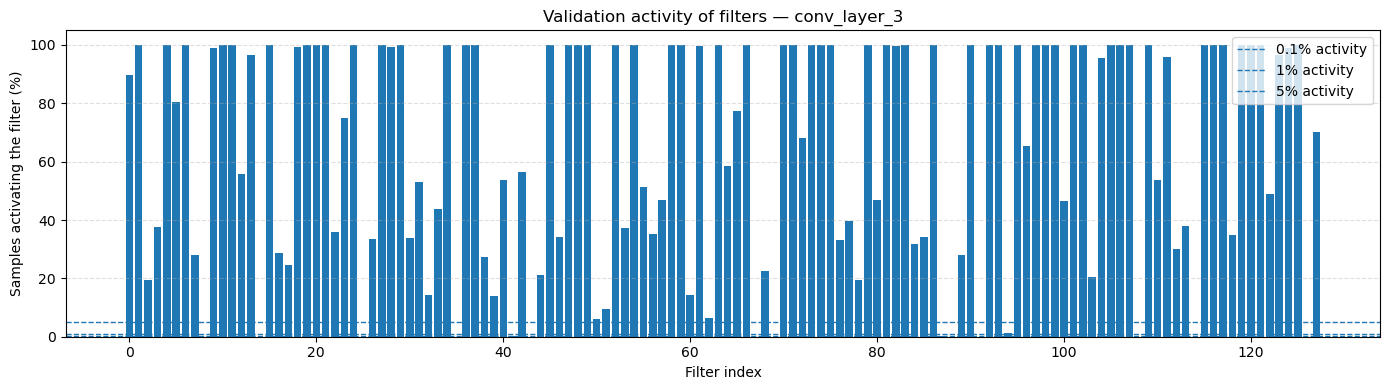

In [37]:
for layer_name in filter_activity["Layer"].unique():
    layer_activity = (
        filter_activity[
            filter_activity["Layer"] == layer_name
        ]
        .sort_values("Filter")
    )

    plt.figure(figsize=(14, 4))

    plt.bar(
        layer_activity["Filter"],
        layer_activity["Sample activity rate"] * 100,
    )

    plt.axhline(
        0.1,
        linestyle="--",
        linewidth=1,
        label="0.1% activity",
    )

    plt.axhline(
        1.0,
        linestyle="--",
        linewidth=1,
        label="1% activity",
    )

    plt.axhline(
        5.0,
        linestyle="--",
        linewidth=1,
        label="5% activity",
    )

    plt.title(
        f"Validation activity of filters — {layer_name}"
    )
    plt.xlabel("Filter index")
    plt.ylabel("Samples activating the filter (%)")
    plt.ylim(
        0,
        max(
            5,
            layer_activity[
                "Sample activity rate"
            ].max() * 105,
        ),
    )
    plt.legend()
    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.4,
    )
    plt.tight_layout()
    plt.show()

In [38]:
CLASS_ACTIVITY_MAX_SAMPLES = 500

class_activity_frames = []
class_sample_records = []

for class_index, class_name in enumerate(class_names):
    class_mask = y_validation == class_index
    class_features = X_validation[class_mask]

    analyzed_class_samples = min(
        CLASS_ACTIVITY_MAX_SAMPLES,
        len(class_features),
    )

    class_filter_activity = (
        analyze_conv_filter_activity(
            model=selected_model,
            features=class_features,
            max_samples=analyzed_class_samples,
            batch_size=128,
            threshold=GLOBAL_ACTIVITY_THRESHOLD,
            seed=SEED + class_index,
        )
    )

    class_filter_activity.insert(
        0,
        "Class",
        class_name,
    )

    class_activity_frames.append(
        class_filter_activity
    )

    class_sample_records.append(
        {
            "Class": class_name,
            "Available validation samples": (
                len(class_features)
            ),
            "Analyzed samples": (
                analyzed_class_samples
            ),
        }
    )

activity_by_class = pd.concat(
    class_activity_frames,
    ignore_index=True,
)

class_sample_table = pd.DataFrame(
    class_sample_records
).set_index("Class")

display(class_sample_table)

,Available validation samples,Analyzed samples
Class,,
center,644,500
donut,83,83
edge-loc,779,500
edge-ring,1452,500
loc,539,500
near-full,22,22
none,22115,500
random,130,130
scratch,179,179


In [39]:
grouped_class_activity = activity_by_class.groupby(
    ["Layer", "Filter"]
)

filter_class_statistics = (
    grouped_class_activity[
        "Sample activity rate"
    ]
    .agg(
        Max_class_activity="max",
        Mean_class_activity="mean",
        Min_class_activity="min",
    )
    .reset_index()
)

most_active_indices = grouped_class_activity[
    "Sample activity rate"
].idxmax()

most_active_classes = (
    activity_by_class.loc[
        most_active_indices,
        [
            "Layer",
            "Filter",
            "Class",
            "Sample activity rate",
        ],
    ]
    .rename(
        columns={
            "Class": "Most active class",
            "Sample activity rate": (
                "Activity in most active class"
            ),
        }
    )
)

filter_class_summary = filter_class_statistics.merge(
    most_active_classes,
    on=["Layer", "Filter"],
    how="left",
)


def assign_cross_class_status(max_activity):
    if max_activity == 0:
        return "Inactive in every class"

    if max_activity <= 0.001:
        return "Almost inactive in every class"

    if max_activity <= 0.01:
        return "Very rarely active"

    if max_activity <= 0.05:
        return "Class-specific or rarely active"

    return "Clearly active"


filter_class_summary["Cross-class status"] = (
    filter_class_summary[
        "Max_class_activity"
    ].map(assign_cross_class_status)
)

cross_class_status_order = [
    "Inactive in every class",
    "Almost inactive in every class",
    "Very rarely active",
    "Class-specific or rarely active",
    "Clearly active",
]

cross_class_summary = pd.crosstab(
    filter_class_summary["Layer"],
    filter_class_summary["Cross-class status"],
).reindex(
    columns=cross_class_status_order,
    fill_value=0,
)

display(cross_class_summary)

display(
    filter_class_summary.sort_values(
        [
            "Max_class_activity",
            "Mean_class_activity",
        ]
    ).head(50).style.format(
        {
            "Max_class_activity": "{:.3%}",
            "Mean_class_activity": "{:.3%}",
            "Min_class_activity": "{:.3%}",
            "Activity in most active class": "{:.3%}",
        }
    )
)

Cross-class status,Inactive in every class,Almost inactive in every class,Very rarely active,Class-specific or rarely active,Clearly active
Layer,,,,,
conv_layer_1,1,0,0,0,31
conv_layer_2,0,0,0,0,64
conv_layer_3,5,0,6,3,114


,Layer,Filter,Max_class_activity,Mean_class_activity,Min_class_activity,Most active class,Activity in most active class,Cross-class status
1,conv_layer_1,1,0.000%,0.000%,0.000%,center,0.000%,Inactive in every class
110,conv_layer_3,14,0.000%,0.000%,0.000%,center,0.000%,Inactive in every class
131,conv_layer_3,35,0.000%,0.000%,0.000%,center,0.000%,Inactive in every class
187,conv_layer_3,91,0.000%,0.000%,0.000%,center,0.000%,Inactive in every class
204,conv_layer_3,108,0.000%,0.000%,0.000%,center,0.000%,Inactive in every class
210,conv_layer_3,114,0.000%,0.000%,0.000%,center,0.000%,Inactive in every class
165,conv_layer_3,69,0.200%,0.022%,0.000%,edge-ring,0.200%,Very rarely active
184,conv_layer_3,88,0.200%,0.022%,0.000%,edge-ring,0.200%,Very rarely active
183,conv_layer_3,87,0.400%,0.044%,0.000%,none,0.400%,Very rarely active
139,conv_layer_3,43,0.400%,0.111%,0.000%,edge-loc,0.400%,Very rarely active


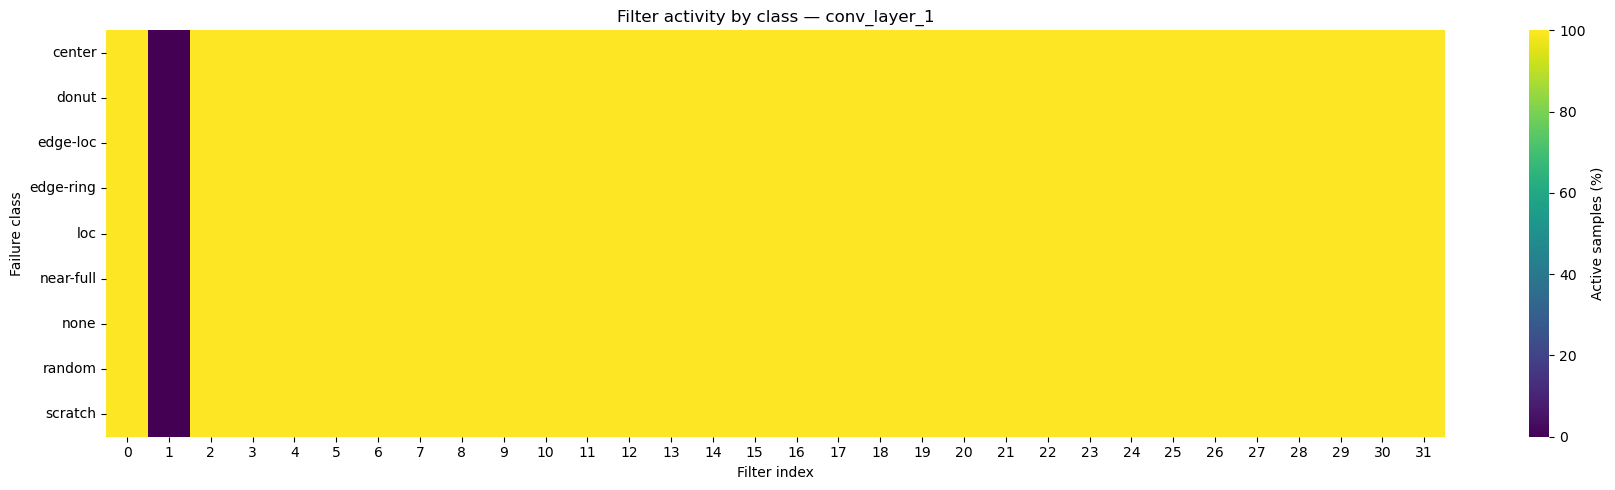

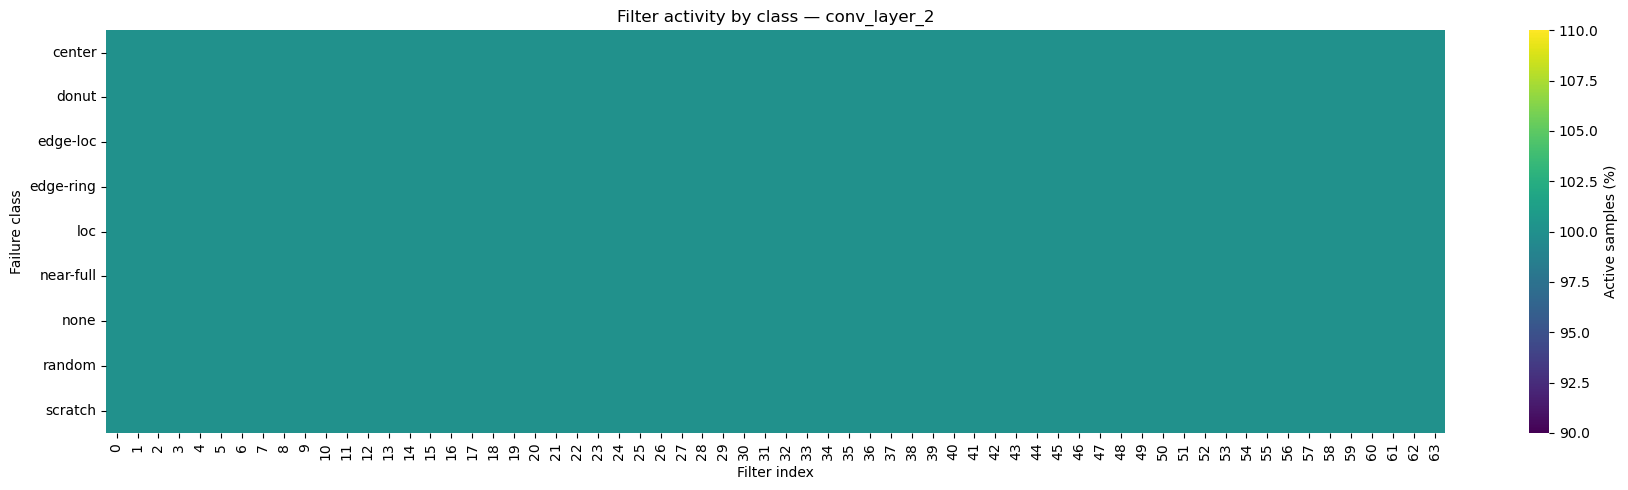

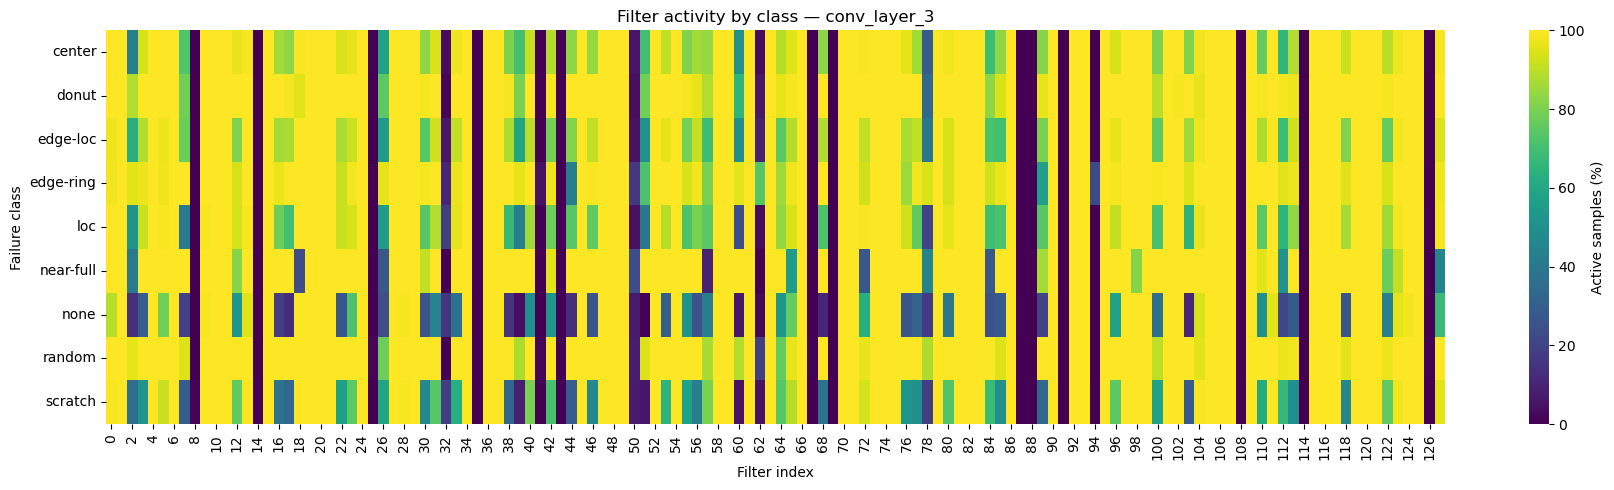

In [40]:
for layer_name in activity_by_class["Layer"].unique():
    layer_class_activity = activity_by_class[
        activity_by_class["Layer"] == layer_name
    ]

    activity_matrix = (
        layer_class_activity.pivot(
            index="Class",
            columns="Filter",
            values="Sample activity rate",
        )
        .reindex(class_names)
        * 100
    )

    plt.figure(figsize=(18, 5))

    sns.heatmap(
        activity_matrix,
        cmap="viridis",
        cbar_kws={
            "label": "Active samples (%)"
        },
    )

    plt.title(
        f"Filter activity by class — {layer_name}"
    )
    plt.xlabel("Filter index")
    plt.ylabel("Failure class")
    plt.tight_layout()
    plt.show()

In [41]:
inactive_filter_candidates = (
    filter_class_summary[
        filter_class_summary[
            "Cross-class status"
        ].isin(
            [
                "Inactive in every class",
                "Almost inactive in every class",
            ]
        )
    ]
    .sort_values(
        [
            "Layer",
            "Max_class_activity",
        ]
    )
)

candidate_counts = (
    inactive_filter_candidates
    .groupby("Layer")
    .size()
    .rename("Inactive candidate filters")
    .to_frame()
)

total_filters_by_layer = (
    filter_class_summary
    .groupby("Layer")
    .size()
    .rename("Total filters")
)

candidate_counts = candidate_counts.join(
    total_filters_by_layer,
    how="right",
).fillna(0)

candidate_counts[
    "Candidate share (%)"
] = (
    candidate_counts[
        "Inactive candidate filters"
    ]
    / candidate_counts["Total filters"]
    * 100
)

display(
    candidate_counts.style.format(
        {
            "Inactive candidate filters": "{:.0f}",
            "Total filters": "{:.0f}",
            "Candidate share (%)": "{:.2f}%",
        }
    )
)

if len(inactive_filter_candidates) == 0:
    print(
        "No filters were inactive across all analyzed classes."
    )
else:
    print(
        "Filters that were inactive or almost inactive "
        "across every analyzed class:"
    )

    display(
        inactive_filter_candidates.style.format(
            {
                "Max_class_activity": "{:.3%}",
                "Mean_class_activity": "{:.3%}",
                "Min_class_activity": "{:.3%}",
                "Activity in most active class": "{:.3%}",
            }
        )
    )

,Inactive candidate filters,Total filters,Candidate share (%)
Layer,,,
conv_layer_1,1,32,3.12%
conv_layer_2,0,64,0.00%
conv_layer_3,5,128,3.91%


Filters that were inactive or almost inactive across every analyzed class:


,Layer,Filter,Max_class_activity,Mean_class_activity,Min_class_activity,Most active class,Activity in most active class,Cross-class status
1,conv_layer_1,1,0.000%,0.000%,0.000%,center,0.000%,Inactive in every class
110,conv_layer_3,14,0.000%,0.000%,0.000%,center,0.000%,Inactive in every class
131,conv_layer_3,35,0.000%,0.000%,0.000%,center,0.000%,Inactive in every class
187,conv_layer_3,91,0.000%,0.000%,0.000%,center,0.000%,Inactive in every class
204,conv_layer_3,108,0.000%,0.000%,0.000%,center,0.000%,Inactive in every class
210,conv_layer_3,114,0.000%,0.000%,0.000%,center,0.000%,Inactive in every class


## Technical consistency audit

This section verifies the dataset, data partitions, model complexity, and checkpoint mapping used in this notebook.

In [42]:
import hashlib
import json
from pathlib import Path

MODEL_FAMILY = "FULL"

EXPECTED_OUTPUT_DIR = (
    PROJECT_DIR / "cnn_outputs"
).resolve()
ACTUAL_OUTPUT_DIR = Path(OUTPUT_DIR).resolve()

if ACTUAL_OUTPUT_DIR != EXPECTED_OUTPUT_DIR:
    raise ValueError(
        "The FULL notebook must use "
        "OUTPUT_DIR = PROJECT_DIR / 'cnn_outputs'.\n"
        f"Current output directory: {ACTUAL_OUTPUT_DIR}"
    )

AUDIT_DIR = OUTPUT_DIR / "audit"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)


def repository_relative_path(path):
    return (
        Path(path)
        .resolve()
        .relative_to(REPO_ROOT.resolve())
        .as_posix()
    )


def sha256_array(array):
    array = np.ascontiguousarray(array)

    digest = hashlib.sha256()
    digest.update(str(array.dtype).encode("utf-8"))
    digest.update(str(array.shape).encode("utf-8"))
    digest.update(array.tobytes())

    return digest.hexdigest()


def sha256_file(path, chunk_size=8 * 1024 * 1024):
    path = Path(path)

    if not path.exists():
        return None

    digest = hashlib.sha256()

    with path.open("rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            digest.update(chunk)

    return digest.hexdigest()


def count_weight_parameters(weights):
    return int(
        sum(np.prod(weight.shape) for weight in weights)
    )


def architecture_signature(model):
    convolution_filters = [
        int(layer.filters)
        for layer in model.layers
        if isinstance(layer, tf.keras.layers.Conv2D)
    ]

    dense_units = [
        int(layer.units)
        for layer in model.layers
        if isinstance(layer, tf.keras.layers.Dense)
    ]

    return {
        "convolution_filters": convolution_filters,
        "dense_units": dense_units,
        "total_parameters": int(model.count_params()),
        "trainable_parameters": count_weight_parameters(
            model.trainable_weights
        ),
        "non_trainable_parameters": count_weight_parameters(
            model.non_trainable_weights
        ),
    }


complexity_records = []

for model_name, model in models.items():
    signature = architecture_signature(model)

    complexity_records.append(
        {
            "Model": model_name,
            "Conv filters": str(
                signature["convolution_filters"]
            ),
            "Dense units": str(
                signature["dense_units"]
            ),
            "Total parameters": (
                signature["total_parameters"]
            ),
            "Trainable parameters": (
                signature["trainable_parameters"]
            ),
            "Non-trainable parameters": (
                signature["non_trainable_parameters"]
            ),
        }
    )

complexity_df = (
    pd.DataFrame(complexity_records)
    .set_index("Model")
    .sort_values("Total parameters")
)

display(complexity_df)

,Conv filters,Dense units,Total parameters,Trainable parameters,Non-trainable parameters
Model,,,,,
Baseline,"[32, 64, 128]","[128, 9]",897673,897225,448
He initialization,"[32, 64, 128]","[128, 9]",897673,897225,448
He + arbitrary rotations,"[32, 64, 128]","[128, 9]",897673,897225,448
He + safe flips,"[32, 64, 128]","[128, 9]",897673,897225,448
He + safe flips + L2,"[32, 64, 128]","[128, 9]",897673,897225,448
Optimizer study — SGD + Nesterov,"[32, 64, 128]","[128, 9]",897673,897225,448
Optimizer study — RMSprop,"[32, 64, 128]","[128, 9]",897673,897225,448
Optimizer study — Nadam,"[32, 64, 128]","[128, 9]",897673,897225,448


In [43]:
checkpoint_records = []

for model_name, checkpoint_path in checkpoints.items():
    checkpoint_path = Path(checkpoint_path)

    checkpoint_records.append(
        {
            "Model": model_name,
            "Checkpoint": str(checkpoint_path),
            "Repository path": repository_relative_path(
                checkpoint_path
            ),
            "Exists": checkpoint_path.exists(),
            "Size (MB)": (
                checkpoint_path.stat().st_size / (1024 * 1024)
                if checkpoint_path.exists()
                else np.nan
            ),
            "SHA256": sha256_file(checkpoint_path),
        }
    )

checkpoint_audit_df = (
    pd.DataFrame(checkpoint_records)
    .set_index("Model")
)

if not checkpoint_audit_df["Exists"].all():
    missing_checkpoints = checkpoint_audit_df.loc[
        ~checkpoint_audit_df["Exists"],
        ["Checkpoint"],
    ]

    raise FileNotFoundError(
        "Some checkpoints are missing:\n"
        f"{missing_checkpoints}"
    )

duplicated_paths = checkpoint_audit_df[
    checkpoint_audit_df["Repository path"].duplicated(
        keep=False
    )
]

if not duplicated_paths.empty:
    raise AssertionError(
        "Multiple models point to the same checkpoint path:\n"
        f"{duplicated_paths[['Repository path']]}"
    )

print("All FULL checkpoint files exist.")
print("Every FULL model uses a distinct checkpoint path.")

All FULL checkpoint files exist.
Every FULL model uses a distinct checkpoint path.


In [44]:
dataset_path = Path(DATASET_PATH)

selected_signature = architecture_signature(
    models[selected_model_name]
)

audit_data = {
    "model_family": MODEL_FAMILY,
    "dataset": {
        "path": repository_relative_path(dataset_path),
        "exists": dataset_path.exists(),
        "sha256": sha256_file(dataset_path),
        "number_of_rows": int(len(df)),
    },
    "splits": {
        "train": {
            "size": int(len(train_indices)),
            "sha256": sha256_array(train_indices),
        },
        "validation": {
            "size": int(len(validation_indices)),
            "sha256": sha256_array(validation_indices),
        },
        "test": {
            "size": int(len(test_indices)),
            "sha256": sha256_array(test_indices),
        },
    },
    "selected_model": {
        "name": selected_model_name,
        **selected_signature,
        "validation_metrics": {
            metric: float(value)
            for metric, value in validation_df.loc[
                selected_model_name
            ].items()
        },
        "test_metrics": {
            metric: float(value)
            for metric, value in test_df.loc[
                selected_model_name
            ].items()
        },
    },
    "checkpoint_paths_are_unique": bool(
        checkpoint_audit_df["Repository path"].is_unique
    ),
}

audit_path = AUDIT_DIR / "full_audit.json"

with audit_path.open("w", encoding="utf-8") as file:
    json.dump(audit_data, file, indent=2)

complexity_df.to_csv(
    AUDIT_DIR / "full_complexity.csv"
)

checkpoint_audit_df.to_csv(
    AUDIT_DIR / "full_checkpoints.csv"
)

print(f"FULL audit saved to: {audit_path.resolve()}")

FULL audit saved to: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\project\cnn_outputs\audit\full_audit.json


In [45]:
checkpoint_verification_records = []

for model_name in test_df.index:
    model = models[model_name]
    checkpoint_path = checkpoints[model_name]

    model.load_weights(checkpoint_path)

    recalculated_metrics, _, _, _ = evaluate_classifier(
        model,
        X_test,
        y_test,
        class_names,
        batch_size=PREDICTION_BATCH_SIZE,
    )

    record = {"Model": model_name}

    for metric_name, recalculated_value in (
        recalculated_metrics.items()
    ):
        stored_value = float(
            test_df.loc[model_name, metric_name]
        )

        record[f"{metric_name} difference"] = abs(
            recalculated_value - stored_value
        )

    checkpoint_verification_records.append(record)

checkpoint_verification_df = (
    pd.DataFrame(checkpoint_verification_records)
    .set_index("Model")
)

display(
    checkpoint_verification_df.style.format(
        "{:.12f}"
    )
)

maximum_difference = float(
    checkpoint_verification_df.to_numpy().max()
)

print(
    "Maximum difference between stored and "
    f"recalculated metrics: {maximum_difference:.12f}"
)

if maximum_difference > 1e-8:
    raise AssertionError(
        "The FULL test table does not match "
        "the current checkpoint files."
    )

print(
    "The FULL test table matches the "
    "current checkpoint files."
)

,Accuracy difference,Balanced Accuracy difference,Macro Precision difference,Macro Recall difference,Macro F1 difference
Model,,,,,
Optimizer study — Nadam,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
Optimizer study — SGD + Nesterov,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
Optimizer study — RMSprop,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
He + safe flips + L2,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
Baseline,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
He + safe flips,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
He initialization,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000
He + arbitrary rotations,0.000000000000,0.000000000000,0.000000000000,0.000000000000,0.000000000000


Maximum difference between stored and recalculated metrics: 0.000000000000
The FULL test table matches the current checkpoint files.
